# DIMER Guided Notebook: Comparing Time-Series Foundation Models for Hourly Zero-Shot Forecasting

**Profile:** `TASK-INFERENCE`
**Mode:** `WORKSHOP`
**Notebook specification:** DIMER Notebook Specification 2.1 — **standalone**
**Run all:** generates or loads a sample, checks it, builds two simple baselines, runs the selected foundation models on a validation period, freezes the experiment, scores an independent test period once, forecasts the next 24 hours and exports a reproducibility record. No DIMER service, repository clone, repository install or credential is required.
**Samples:** a synthetic two-series sample (default) or real hourly temperature for Manila, Cebu and Davao (`SAMPLE_DATASET = "OPEN_METEO_PH"`)
**Bring your own data:** set `BYOD_CSV_PATH` or `USE_BYOD` in Section 1
**Models:** TiRex-2 and Chronos-2 (`STANDARD` tier, default); Toto 2.0 2.5B added in the `FULL` tier
**Task:** forecast the next 24 hourly values of each series, with a middle estimate and a low–high range
**Primary comparison:** mean absolute error (MAE) and skill against a seasonal-naive baseline
**Recommended audience:** readers who know some Python and are new to forecasting and machine learning

---

## What you will do

1. Generate or load a small hourly dataset and check that it is exactly the expected data.
2. Look at the series: level, trend, the 24-hour cycle and where the data is split.
3. Build two simple baselines that any forecasting model must beat.
4. Run pretrained forecasting models on the same history, with no training.
5. Compare them with one set of metrics, for both accuracy and uncertainty.
6. Freeze your choices, then score an independent test period once.
7. Weigh accuracy against model size and runtime.
8. Forecast the real future and export a record of the experiment.

> **Important:** This is a training exercise. The samples are small and are not benchmark evidence. The notebook does not declare a universally best model.

### Task at a glance

**Input:** regular hourly observations for each series → **Model/System:** last-value and seasonal-naive baselines plus frozen pretrained forecasting models → **Output:** the next 24 hourly median predictions, q10–q90 bands, held-out metrics and an experiment record.


## How to use this notebook

**Who it is for.** You can read Python and run a Colab notebook, but you are new to forecasting. Every new term is explained where it first appears in a **Key term** note, and the **Glossary** at the end collects them all.

**How to run it.**

1. Select **Runtime → Change runtime type**, choose a **T4 GPU**, and select **Save**.
2. Select **Runtime → Run all**. The default settings run the whole notebook.
3. Read each section's text while its cells run. Cells with a form on the right are settings you may change; the defaults are the reference settings.

**Reading the cells.** The setup cells in Section 6 build software environments and write the model programs. You can run them without reading their code; the text above each one says what it does. The cells worth reading closely are the data checks, the baselines, the result tables and the plots.

**Checkpoints.** Several sections end with questions. Write your own answer first, then expand **Show a sample answer** to compare. Sample answers quote the reference runs on a Colab T4; your numbers should match closely, because the samples are fixed.

### Roadmap

| Section | What happens | Time on a Colab T4 |
|---|---|---|
| Know your data | Read about the samples, the models and the rules | Reading only |
| 1–2. Settings and models | Choose the tier and sample; list the models | Seconds |
| 3–4. Data | Load, check and plot the sample | Seconds |
| 5. Baselines and metrics | Split the data, build the baselines | Seconds |
| 6. Model environments | Install each model's software | Several minutes on the first run |
| 7. Validation | Forecast the validation period with each model | About 10–25 seconds per model, plus the first weight download |
| 8–9. Freeze and test | Freeze the choices, score the test period | About the same as validation |
| 10–13. Interpret and export | Trade-offs, future forecast, conclusion, export | Seconds |

### Choosing a tier and a sample

- `WORKSHOP_TIER = "STANDARD"` runs TiRex-2 and Chronos-2 and is the default. `"FULL"` adds Toto 2.0, a 9.8 GB checkpoint that needs a CUDA GPU and much more time and disk. Use `FULL` only on an instructor machine or a session with the weights already downloaded.
- `SAMPLE_DATASET = "SYNTHETIC"` is the default: clean, formula-made data where every result can be explained. `"OPEN_METEO_PH"` is real temperature data, where the answers are less tidy. Running both, one after the other, is the most instructive order.

If something fails, see **Troubleshooting** at the end of the notebook.

**Reading guide.** **Core concept** sections explain the task and predictions. **Evaluation practice** sections explain comparisons and held-out evidence. **Infrastructure** sections handle environments, model programs and export; you may run their collapsed code without studying it. The optional validation-only activity at the end takes seconds and does not change the frozen experiment.


## Research-design context

**Evaluation practice.**

The notebook uses a comparative experimental pattern:

- define one forecasting task;
- hold the data, the forecast periods and the evaluation constant;
- compare several pretrained models and two simple baselines;
- score them all with one evaluator; and
- ask whether the extra model complexity adds value.

### Main research question

> Given exactly the same history, forecast length, quantiles and evaluation periods, how do different pretrained forecasting models behave, and do they beat a simple seasonal baseline?

### Learning objectives

By the end of this notebook you should be able to:

- set up a leakage-safe chronological forecasting experiment;
- distinguish context, forecast origin and forecast horizon;
- compare foundation-model forecasts with last-value and seasonal-naive baselines;
- interpret MAE, RMSE, skill, pinball loss, interval coverage and interval width;
- distinguish model quantiles from calibrated confidence intervals;
- freeze choices before viewing an independent test period;
- compare forecast quality with model size and runtime; and
- repeat the workflow with your own regularly sampled time series.


# Know your data

**Core concept.**

Read this section before running anything. Every result later in the notebook makes sense only if you know what the data describes and how it is split.

## What a row means

Both samples use the same **long format**: one row per series per timestamp.

```text
series_id,timestamp,target
A,2026-01-01T00:00:00,120.0
A,2026-01-01T01:00:00,121.7329
...
B,2026-01-01T00:00:00,155.0
...
```

| Column | Meaning |
|---|---|
| `series_id` | Which series the row belongs to, for example `A` or `manila` |
| `timestamp` | The hour the value describes. Every series has exactly the same hourly timestamps |
| `target` | The value to forecast |

> **Key term — time series.** A sequence of values of one quantity recorded at regular times, here once per hour. The order matters: a value at 10:00 comes after 09:00, and a forecast may only use values from before the time it forecasts.

> **Key term — frequency and seasonal period.** The **frequency** is the spacing between timestamps, here one hour. A **seasonal period** is the length of a repeating cycle, here 24 hours, so the value at 14:00 tends to resemble yesterday's value at 14:00.

## Sample 1 — synthetic series (default)

The default sample, `chronos_multi_series.csv`, is the synthetic two-series sample from this pipeline repository's `examples/sample-data/generate_samples.py`. The notebook recreates it from the formulas below, with no random draw, and checks its SHA-256 before continuing.

For hour `t = 0..95`, starting 2026-01-01 00:00:

| Series | Formula | What it shows |
|---|---|---|
| `A` | `120 + 0.18*t + 6*sin(2*pi*t/24)` | Rises about 4.3 per day; daily swing of ±6 |
| `B` | `155 + 0.12*t + 9*sin(2*pi*(t+5)/24)` | Higher level; rises about 2.9 per day; daily swing of ±9, 5 hours ahead of `A` |

- 2 series × 96 hourly values = 192 rows, no noise, no missing values;
- original synthetic data under the repository's Apache-2.0 licence;
- SHA-256 `6f12f1475411aaab13a2de860ba50f008bd7185a9266f99147c244db4a5de8b3`.

The source fixture defines two aligned synthetic series. This notebook presents them as a common two-channel numerical target matrix. This does not imply a causal or physical relationship between the two variables.

Because the data has a clean 24-hour cycle and a steady trend, a **24-hour seasonal-naive baseline is strong** here. That is deliberate: a sophisticated model must earn its complexity.

## Sample 2 — real hourly temperature (optional)

Set `SAMPLE_DATASET = "OPEN_METEO_PH"` to use real weather: hourly air temperature at 2 m for **Manila, Cebu and Davao**, from 2026-08-26 00:00 to 2026-09-08 23:00 UTC.

- 3 series × 336 hours = 1,008 rows; one shared hourly grid; no gaps;
- values in °C with one decimal place;
- embedded in this notebook and checked against SHA-256 `74163ee609cda87869b7c13f4c2aa59343f94b4ba42d2e57331034902fe04f1a`, so no download is needed;
- source: the [Open-Meteo](https://open-meteo.com/) historical weather API. Its licence is **CC BY 4.0**, so credit **"Weather data by Open-Meteo.com"** wherever you show or share results;
- how it was fetched, and its limitations: `examples/byod-data/open-meteo-ph-temperature/` in the Chronos-2 pipeline repository.

Three details are easy to miss:

1. **Timestamps are UTC.** Philippine time is UTC+8, so the afternoon temperature peak appears at about 03:00–06:00 UTC in the plots.
2. **The values describe a model grid cell, not a weather station.** Open-Meteo estimates weather for grid cells several kilometres across.
3. **The daily cycle differs by city.** In this sample, Davao swings about 7 °C a day, Cebu about 6 °C and Manila about 2 °C.

## How the data is split in time

The final part of each series is held back and split into two periods:

```text
synthetic sample (96 hours)
hour: 0 ................... 47 | 48 ........ 71 | 72 ........ 95 | 96 ... 119
      validation context        validation       test             future
      |-------- test context ----------------- |                 (not measurable)
      |------------------ future context --------------------- |

Open-Meteo sample (336 hours)
      2026-08-26 ... 2026-09-06 | 2026-09-07 | 2026-09-08 | 2026-09-09
      validation context          validation   test         future
```

- **Validation forecast:** the models see only the validation context and forecast the next 24 hours. These scores are used to compare models and settings.
- **Test forecast:** after the experiment is frozen, the models see everything before the test period, including the validation hours, and forecast the test period once.
- **Future forecast:** the models see all the data and forecast the 24 hours after it ends. There is no truth to score yet.

> **Key term — forecast origin, context and horizon.** The **forecast origin** is the last hour the model is allowed to see. The **context** is the history up to the origin. The **horizon** is how many future steps are forecast, here 24.

> **Key term — validation and test periods.** The **validation period** is used to compare models and make choices. The **test period** is kept aside for one final, honest measurement. If you look at test results while still making choices, the test score stops being an honest estimate.

> **Key term — leakage.** Information from the period being forecast reaching the model or your choices. Using test values to pick a model, or future values as inputs, is leakage and makes scores look better than they will be in practice.

## The foundation models

> **Key term — foundation model.** A large model pretrained on a broad collection of data so that it can be applied to new tasks with little or no task-specific training. The models here were pretrained on many time series from different domains.

> **Key term — zero-shot forecasting.** Forecasting a series the model has never seen, using only its pretrained weights and the series' own history. Nothing is trained or fine-tuned in this notebook.

| Model | Checkpoint size | Where it runs here | Tier | Weight licence |
|---|---:|---|---|---|
| TiRex-2 (`NX-AI/TiRex-2`) | about 381 MB | CPU | `STANDARD` and `FULL` | Apache-2.0 |
| Chronos-2 (`amazon/chronos-2`) | about 478 MB | GPU when available, otherwise CPU | `STANDARD` and `FULL` | Apache-2.0 |
| Toto 2.0 2.5B (`Datadog/Toto-2.0-2.5B`) | about 9.8 GB | CUDA GPU only | `FULL` only | Apache-2.0 |

All three models get **exactly the same input**: the target history, with no extra variables. TiRex-2 and Chronos-2 can also use extra known inputs (covariates), but Toto's open interface here cannot, so giving covariates to some models would make the comparison unfair. Each model returns a forecast at three **quantiles**: 0.1, 0.5 and 0.9.

> **Key term — quantile forecast.** A forecast of a value below which the model expects the truth to fall a stated fraction of the time. q0.5 is the **model median**: the model's middle estimate, not its mean. q0.1 and q0.9 give a low and a high value; the q10–q90 band is described by **model quantiles**, not a guaranteed 80% confidence interval.

## Before you begin

**Requirements.** A current Google Colab runtime with internet access, to install packages and download the pinned model checkpoints from their public hosts. `STANDARD` needs about 1 GB of downloads plus packages; `FULL` needs more than 10 GB and a CUDA GPU.

**Test-period rule.** Choose the models, the horizons and the metrics using the validation period only. Section 8 freezes those choices before the test period is scored.

**Your own data.** Section 3 explains how to use your own CSV. User-supplied data remain inside the selected notebook runtime and are not submitted to a DIMER worker or API. A hosted notebook remains an external compute environment. Do not upload confidential, personal, security-sensitive, restricted, regulated, or proprietary operational telemetry unless you are authorized to process it there.


# 1. Choose the settings and check the runtime

**Infrastructure.**

The first cell holds the settings. The defaults reproduce the reference run.

| Setting | What it does |
|---|---|
| `WORKSHOP_TIER` | `STANDARD` runs TiRex-2 and Chronos-2; `FULL` adds Toto 2.0 |
| `SAMPLE_DATASET` | `SYNTHETIC` or `OPEN_METEO_PH` |
| `USE_BYOD`, `BYOD_CSV_PATH` | Use your own CSV instead of a sample; see Section 3 |
| `VALIDATION_HORIZON`, `TEST_HORIZON` | Hours in the validation and test periods; 24 each by default |
| `SEASON_LENGTH` | Length of the daily cycle used by the seasonal-naive baseline; 24 hours |

The second cell checks the notebook's own Python. The models do not run in it: Section 6 gives each model its own pinned Python 3.12 environment, so the notebook works on Colab's current Python 3.13.


In [1]:
# @title 1.1 Notebook controls
WORKSHOP_TIER = "STANDARD"  # @param ["STANDARD", "FULL"]
USE_BYOD = False            # @param {type:"boolean"}
BYOD_CSV_PATH = ""          # @param {type:"string"}
SAMPLE_DATASET = "OPEN_METEO_PH"  # @param ["SYNTHETIC", "OPEN_METEO_PH"]
OUTPUT_DIR = "outputs"      # @param {type:"string"}

VALIDATION_HORIZON = 24     # @param {type:"integer"}
TEST_HORIZON = 24           # @param {type:"integer"}
SEASON_LENGTH = 24          # @param {type:"integer"}

QUANTILES = (0.1, 0.5, 0.9)
COMMON_MAX_CONTEXT = 8192
COMMON_MAX_HORIZON = 1024
COMMON_MIN_CONTEXT = 32

if SAMPLE_DATASET not in {"SYNTHETIC", "OPEN_METEO_PH"}:
    raise ValueError("SAMPLE_DATASET must be SYNTHETIC or OPEN_METEO_PH")
if WORKSHOP_TIER not in {"STANDARD", "FULL"}:
    raise ValueError("WORKSHOP_TIER must be STANDARD or FULL")
if not 1 <= VALIDATION_HORIZON <= COMMON_MAX_HORIZON:
    raise ValueError("VALIDATION_HORIZON outside the common 1..1024 contract")
if not 1 <= TEST_HORIZON <= COMMON_MAX_HORIZON:
    raise ValueError("TEST_HORIZON outside the common 1..1024 contract")
if SEASON_LENGTH < 1:
    raise ValueError("SEASON_LENGTH must be positive")

SELECTED_MODELS = ["tirex", "chronos"] + (["toto"] if WORKSHOP_TIER == "FULL" else [])

from pathlib import Path
OUTPUT_ROOT = Path(OUTPUT_DIR)
WORK_ROOT = Path("work")
for path in [
    OUTPUT_ROOT / "data",
    OUTPUT_ROOT / "validation",
    OUTPUT_ROOT / "frozen",
    OUTPUT_ROOT / "test",
    OUTPUT_ROOT / "future",
    OUTPUT_ROOT / "figures",
    OUTPUT_ROOT / "provenance",
    WORK_ROOT / "envs",
    WORK_ROOT / "runners",
    WORK_ROOT / "model_cache",
    WORK_ROOT / "requests",
    WORK_ROOT / "run_metadata",
]:
    path.mkdir(parents=True, exist_ok=True)

print({
    "tier": WORKSHOP_TIER,
    "sample_dataset": SAMPLE_DATASET,
    "selected_models": SELECTED_MODELS,
    "validation_horizon": VALIDATION_HORIZON,
    "test_horizon": TEST_HORIZON,
    "season_length": SEASON_LENGTH,
    "output_root": str(OUTPUT_ROOT.resolve()),
})

{'tier': 'STANDARD', 'sample_dataset': 'OPEN_METEO_PH', 'selected_models': ['tirex', 'chronos'], 'validation_horizon': 24, 'test_horizon': 24, 'season_length': 24, 'output_root': '/content/outputs'}


In [2]:
# @title 1.2 Check the notebook runtime
import importlib.metadata
import platform
import sys

if sys.version_info[:2] < (3, 10):
    raise RuntimeError(
        f"The parent notebook runtime needs Python 3.10 or newer; "
        f"current runtime is {platform.python_version()}."
    )

# The heavy model stacks run in isolated virtual environments pinned to
# MODEL_ENV_PYTHON (built in Section "Build selected isolated environments"),
# so the parent kernel's own Python version does not constrain them. The parent
# runtime only owns orchestration, validation, tables and figures.
for package in ("numpy", "pandas", "matplotlib", "packaging"):
    try:
        print(package, importlib.metadata.version(package))
    except importlib.metadata.PackageNotFoundError as exc:
        raise RuntimeError(f"Parent runtime is missing required package: {package}") from exc

print({
    "python": platform.python_version(),
    "platform": platform.platform(),
    "executable": sys.executable,
})

numpy 2.1.3
pandas 2.2.3
matplotlib 3.10.0
packaging 26.3
{'python': '3.13.15', 'platform': 'Linux-6.6.122+-x86_64-with-glibc2.39', 'executable': '/usr/bin/python3'}


### Expected result

You should see the tier, the sample, the selected models and the output folder, then the versions of `numpy`, `pandas`, `matplotlib` and `packaging` and the notebook's Python version. Record them: software versions can affect results.


# 2. The models being compared

**Core concept.**

Each model is pinned to an exact **revision**, and each checkpoint file to an exact size and SHA-256 fingerprint. Section 6 refuses a file that does not match.

> **Key term — pinned revision.** A specific, unchangeable version of a model repository, identified by its commit hash. Downloading a pinned revision rather than the latest one means later changes upstream cannot change your results.

The comparison uses only what all selected models support:

- finite numerical values on a regular hourly grid;
- no extra input variables;
- at most 8,192 hours of context and 1,024 hours of horizon (Chronos-2's limits);
- quantiles 0.1, 0.5 and 0.9, with the point forecast equal to q0.5.


In [3]:
# @title 2.1 Pinned model identities and footprint
MODEL_SPECS = {
    "tirex": {
        "display_name": "TiRex-2",
        "model_id": "NX-AI/TiRex-2",
        "revision": "05e5b26db52bfb256f1ae1bdf785589850482de3",
        "license": "Apache-2.0",
        "runtime_package": "tirex-2==0.2.1",
        "files": {
            "README.md": (5521, "ec10f277ff820fb8915b4ff3988916c25bc892167902aba84bb9bfe24d190b70"),
            "model-config.yaml": (1204, "cddbe6d0be4919cb7b0cad747fb19a295264e129d1c0790cf62133b4cb5da727"),
            "model.ckpt": (380613375, "184b160ffbe4c01a26beeba14015ff3507c7497e1f3577114187bbc1d19fcac1"),
        },
        "weight_bytes": 380613375,
        "device": "CPU",
    },
    "chronos": {
        "display_name": "Chronos-2",
        "model_id": "amazon/chronos-2",
        "revision": "95a9710e2596287d08352589f42634fa5abdf0a7",
        "license": "Apache-2.0",
        "runtime_package": "chronos-forecasting==2.3.1",
        "files": {
            "README.md": (31, "4bcf87ecfbbb8e07a01b21415a970c8b53a5283bf6872b657040d3f45c9241f7"),
            "config.json": (1067, "ef1143bfdc9c0376d9a056eefca46cb4b1ec3d0ffacd541ff56feb40fb708031"),
            "model.safetensors": (477930472, "ddcda3c7508bf2528087723e98a20707cc04b7f370ae275a9fd88078ddba4f42"),
        },
        "weight_bytes": 477930472,
        "device": "CPU/GPU",
    },
    "toto": {
        "display_name": "Toto 2.0 2.5B",
        "model_id": "Datadog/Toto-2.0-2.5B",
        "revision": "51a2812bbe449437c01b79c0e425ed578f335f5b",
        "license": "Apache-2.0",
        "runtime_package": "toto-2==2.0.0",
        "files": {
            "README.md": (7188, "5cd75f3d08d1574c085ee31a2886855d82247f76cb3bd0b8015750a7fc1d316d"),
            "config.json": (598, "172904c65bb5af77a95e1a81cdd9214f4c9d983651d6dceef1375d3d09f47a36"),
            "model.safetensors": (9817176960, "dc08942b20751ac906167194d4ca4aa06b4367e80aabe5f1d5153b30b874bdb9"),
        },
        "weight_bytes": 9817176960,
        "device": "CUDA GPU",
    },
}

import pandas as pd
display(pd.DataFrame([
    {
        "model": MODEL_SPECS[key]["display_name"],
        "model_id": MODEL_SPECS[key]["model_id"],
        "revision": MODEL_SPECS[key]["revision"][:12] + "…",
        "weights_MiB": round(MODEL_SPECS[key]["weight_bytes"] / 2**20, 1),
        "reference_device": MODEL_SPECS[key]["device"],
        "selected": key in SELECTED_MODELS,
    }
    for key in MODEL_SPECS
]))

,model,model_id,revision,weights_MiB,reference_device,selected
0,TiRex-2,NX-AI/TiRex-2,05e5b26db52b…,363.0,CPU,True
1,Chronos-2,amazon/chronos-2,95a9710e2596…,455.8,CPU/GPU,True
2,Toto 2.0 2.5B,Datadog/Toto-2.0-2.5B,51a2812bbe44…,9362.4,CUDA GPU,False


### Expected result

A table with one row per model: identity, revision, checkpoint size in MiB, reference device, and whether it is selected. In `STANDARD`, Toto shows `selected = False`.


# 3. Load and check the data

**Evaluation practice.**

The next cell builds the selected sample and checks its SHA-256 fingerprint. If the bytes differ from the published sample, it stops rather than continuing with different data.

> **Key term — SHA-256 digest.** A 64-character fingerprint computed from every byte of a file. If a single byte changes, the fingerprint changes completely. Matching fingerprints show that everyone in the workshop is using identical data.

## Bring your own data (optional)

You can run the same experiment on your own hourly (or other regularly spaced) data.

1. Prepare one CSV in the long format above: columns `series_id`, `timestamp` and `target`.
2. Every series must have the same timestamps, evenly spaced, with no gaps and no missing values.
3. You need at least 32 + `VALIDATION_HORIZON` + `TEST_HORIZON` values per series: 80 with the defaults.
4. To use a file already in the runtime, for example in a mounted Google Drive, enter its path in `BYOD_CSV_PATH` in Section 1. To upload from your computer instead, select `USE_BYOD` and pick the file when the cell runs.

Your own file takes precedence over `SAMPLE_DATASET`. It has no published fingerprint, so the notebook records its digest but cannot check it.

The notebook does **not** impute missing values, interpolate gaps, resample, or silently fix irregular timestamps. It stops and names the problem instead.


In [4]:
# @title 3.1 Generate or load the sample
import csv
import hashlib
import io
import json
import os
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd

CANONICAL_SAMPLE_SHA256 = "6f12f1475411aaab13a2de860ba50f008bd7185a9266f99147c244db4a5de8b3"

def canonical_sample_bytes():
    n = 96
    timestamps = pd.date_range("2026-01-01", periods=n, freq="h")
    step = np.arange(n, dtype=float)
    parts = []
    for series_id, offset, slope, amplitude, phase in (
        ("A", 0.0, 0.18, 6.0, 0.0),
        ("B", 35.0, 0.12, 9.0, 5.0),
    ):
        target = (
            120.0
            + offset
            + slope * step
            + amplitude * np.sin(2.0 * np.pi * (step + phase) / 24.0)
        )
        parts.append(pd.DataFrame({
            "series_id": series_id,
            "timestamp": timestamps,
            "target": target,
        }))
    frame = pd.concat(parts, ignore_index=True)
    payload = frame.to_csv(
        index=False,
        date_format="%Y-%m-%dT%H:%M:%S",
        float_format="%.4f",
        lineterminator="\n",
    ).encode("utf-8")
    return payload

# Real-data sample: Open-Meteo hourly air temperature at 2 m, 2026-08-26..2026-09-08 UTC.
# Embedded copy of examples/byod-data/open-meteo-ph-temperature/openmeteo_ph_hourly_temperature.csv
# in the pipeline repository (see its DATASET_CARD.md for the request and provenance).
# Licence: CC BY 4.0. Attribution: "Weather data by Open-Meteo.com".
OPEN_METEO_PH_SHA256 = "74163ee609cda87869b7c13f4c2aa59343f94b4ba42d2e57331034902fe04f1a"
OPEN_METEO_PH_START = "2026-08-26 00:00"
OPEN_METEO_PH_VALUES = {
    "manila": (
        "29.0 29.8 30.7 30.4 30.5 29.9 31.7 30.6 29.5 29.0 28.4 27.5 28.6 28.0 28.0 27.6 27.5 27.5 27.8 27.4 27.1 27.3 27.2 27.4 "
        "28.2 28.8 29.2 29.7 29.2 29.3 30.3 29.8 28.9 28.8 28.3 27.8 27.0 27.0 26.7 26.6 26.1 26.4 27.0 26.7 26.3 26.4 26.3 26.5 "
        "25.5 25.9 25.8 26.4 26.1 26.5 26.3 26.0 25.9 26.0 25.8 25.8 25.5 25.1 25.7 25.9 25.7 25.7 25.6 25.8 25.8 25.6 25.5 26.0 "
        "25.7 25.6 25.7 26.2 26.1 27.0 26.3 26.6 25.6 26.1 26.0 26.6 26.6 26.9 27.3 27.5 27.2 27.2 27.7 27.4 26.9 26.7 26.1 26.4 "
        "27.0 27.1 27.9 28.5 28.5 28.5 27.1 28.0 27.5 27.6 27.2 26.8 27.9 28.1 27.2 26.4 27.8 27.2 27.8 27.4 27.8 27.1 25.8 26.7 "
        "28.4 28.9 29.2 29.4 29.7 30.6 31.0 30.7 30.3 29.7 29.2 29.1 29.1 29.0 28.9 29.0 28.9 28.7 28.5 28.3 27.7 27.8 27.6 27.9 "
        "28.5 29.7 29.7 29.9 30.1 30.0 30.6 30.4 30.1 29.5 29.1 28.8 26.8 27.8 28.3 28.7 28.1 27.6 28.3 27.7 27.4 27.6 27.5 27.9 "
        "29.1 29.5 30.3 29.8 29.5 29.1 29.6 29.6 28.7 28.1 27.5 28.0 28.7 27.6 27.6 27.6 27.9 27.8 28.0 27.3 26.1 26.6 26.8 26.8 "
        "28.5 29.0 28.7 29.7 29.6 29.3 29.8 29.0 28.9 27.8 27.3 26.9 26.5 26.2 25.9 25.8 26.0 26.0 26.2 26.0 26.0 26.2 26.6 27.0 "
        "27.0 27.8 27.8 27.9 27.9 28.4 28.1 28.1 28.0 28.1 27.5 27.2 26.2 25.9 26.3 26.3 26.4 26.2 26.1 25.5 25.7 25.9 26.0 26.7 "
        "26.5 26.4 26.8 27.3 27.4 27.2 27.0 26.5 26.4 26.4 26.0 26.1 25.8 26.0 26.0 26.0 26.1 26.4 25.7 25.9 25.8 26.3 26.6 26.3 "
        "27.5 28.0 27.0 27.1 28.1 27.7 27.8 27.7 27.3 26.8 27.0 27.1 26.6 26.8 26.8 26.1 25.7 26.3 26.1 26.3 26.4 26.4 26.3 26.1 "
        "27.0 27.0 27.1 27.5 26.3 26.2 27.1 26.7 26.3 26.2 26.1 26.0 26.5 26.4 26.3 26.2 26.0 25.8 25.5 25.6 25.6 25.7 25.9 26.1 "
        "26.8 25.5 26.2 26.4 27.8 28.0 27.2 27.7 27.5 26.7 26.4 26.3 25.5 25.4 25.7 25.6 25.7 25.6 26.4 26.2 26.1 25.6 25.1 24.5 "
    ),
    "cebu": (
        "30.8 31.8 32.5 32.1 31.7 31.2 31.9 30.7 30.3 30.0 29.1 28.6 28.9 28.6 28.2 27.8 27.6 27.3 27.2 26.9 26.8 26.8 26.9 28.2 "
        "29.9 31.0 32.0 32.8 32.4 31.6 29.7 28.9 26.6 26.7 26.5 26.3 27.8 27.3 26.7 26.1 25.8 25.7 26.0 26.1 26.5 26.5 26.4 27.1 "
        "27.8 29.3 30.9 31.4 31.7 31.4 31.3 31.9 31.0 29.9 29.4 29.0 29.2 28.5 28.0 27.7 27.6 27.9 28.4 28.0 27.9 27.8 27.8 28.6 "
        "30.5 31.1 31.7 31.6 31.0 31.1 33.5 33.1 32.2 31.7 30.7 29.9 29.5 29.0 28.5 28.2 27.9 27.8 27.6 27.4 27.2 27.0 27.1 28.2 "
        "30.2 31.3 32.2 32.6 33.1 32.7 33.8 31.9 32.5 31.7 30.4 29.7 29.0 28.4 28.3 28.0 27.7 27.5 27.1 27.1 27.1 27.0 27.1 28.5 "
        "30.4 31.3 31.8 32.0 32.0 31.3 33.6 33.0 32.4 31.9 31.0 30.0 29.7 29.1 28.7 28.2 27.8 27.6 27.3 27.0 26.9 26.8 27.0 28.6 "
        "30.6 31.3 32.3 32.2 31.4 30.2 32.8 32.2 30.8 30.8 29.8 28.9 28.8 28.2 27.9 27.5 27.3 27.2 27.0 26.8 26.7 26.6 26.8 28.3 "
        "30.5 31.6 32.2 32.5 32.2 31.9 32.7 32.5 31.9 30.8 29.7 29.4 29.5 28.9 28.5 28.1 28.0 27.9 27.7 27.5 27.4 27.2 27.3 28.7 "
        "30.7 31.2 31.3 31.0 31.7 32.4 33.1 32.0 31.4 30.6 29.8 29.5 29.5 29.0 28.5 28.1 27.8 27.6 27.6 27.4 27.3 27.3 27.5 28.8 "
        "30.5 30.9 31.2 31.3 31.4 31.6 32.8 32.6 31.9 31.1 30.1 29.9 28.2 28.0 28.0 27.9 27.6 27.5 27.1 26.6 26.3 26.0 26.3 28.0 "
        "30.6 31.9 32.8 32.5 31.7 32.7 33.8 31.8 31.9 30.3 29.0 28.2 28.0 27.5 27.7 27.5 27.1 26.9 27.2 26.9 26.6 26.5 26.6 28.4 "
        "30.4 31.2 31.4 31.5 31.9 32.5 33.5 33.5 31.4 30.8 30.0 29.4 29.7 29.2 28.7 28.2 27.7 27.4 27.5 27.2 27.0 26.9 26.9 28.5 "
        "30.7 31.7 32.9 33.1 33.2 32.8 33.9 32.5 32.1 31.3 29.7 28.8 29.2 28.9 28.8 28.6 28.2 28.0 27.7 27.4 27.2 27.0 27.2 28.8 "
        "30.7 31.9 33.2 33.7 33.7 33.6 34.4 33.3 32.5 31.4 30.3 29.5 29.6 29.2 28.8 28.6 28.2 27.9 27.8 27.4 27.2 27.0 26.9 28.4 "
    ),
    "davao": (
        "26.7 27.7 28.8 29.4 29.9 29.7 29.5 28.4 27.3 27.3 26.5 25.9 25.6 24.9 24.6 24.6 24.6 24.5 24.2 23.8 23.9 23.7 23.8 25.0 "
        "26.3 27.6 28.7 28.5 29.3 29.0 29.3 28.1 27.6 26.8 26.0 25.7 25.7 25.2 24.9 24.7 24.6 24.5 23.9 23.8 23.6 23.2 23.4 25.8 "
        "26.8 27.7 27.9 28.5 28.7 29.3 30.2 28.1 27.8 26.9 25.7 25.4 25.7 25.3 25.2 25.1 24.7 24.2 24.2 23.8 23.6 23.1 23.3 25.5 "
        "26.5 28.0 29.2 29.9 30.8 31.1 30.7 29.9 29.5 28.1 26.6 26.2 25.9 25.4 25.1 24.8 24.1 23.3 23.3 22.8 22.3 22.0 22.4 25.2 "
        "26.9 28.1 28.8 29.4 29.7 30.1 30.2 28.7 28.0 26.9 25.8 25.5 25.6 25.4 25.2 24.8 24.4 24.0 23.9 23.4 22.8 22.3 22.3 25.3 "
        "27.2 28.4 29.3 30.1 30.4 30.5 30.5 29.7 28.7 27.7 26.4 25.8 25.8 25.8 25.6 25.6 25.1 24.5 24.8 24.1 24.0 23.7 23.9 25.4 "
        "27.0 27.7 28.9 29.4 30.5 30.4 30.7 29.7 28.9 27.8 26.3 25.9 26.2 25.9 25.6 25.2 24.7 24.4 24.3 23.6 23.3 22.9 23.3 25.5 "
        "27.0 28.4 29.4 29.8 30.5 30.9 30.6 29.4 28.3 27.3 26.4 26.0 26.3 26.2 25.9 25.3 25.0 24.8 24.7 24.3 24.0 23.6 23.9 25.9 "
        "27.5 28.3 29.4 30.0 30.6 30.8 30.7 29.2 27.8 27.1 26.2 25.9 25.8 25.5 25.4 25.2 25.1 24.9 24.5 23.8 23.8 23.6 23.7 26.0 "
        "27.6 28.8 29.5 30.0 30.6 30.7 30.7 29.0 28.3 27.3 26.4 26.1 26.3 25.9 25.6 25.2 25.0 24.5 24.2 23.7 23.5 23.2 23.6 25.9 "
        "27.8 28.5 29.4 29.8 30.1 30.0 29.7 29.3 28.3 26.8 26.2 25.9 25.7 25.6 25.3 25.0 24.9 24.5 24.2 23.8 23.6 23.4 23.7 25.9 "
        "27.8 29.0 30.0 30.2 31.2 30.8 31.0 29.3 28.0 27.3 26.2 26.0 26.1 25.5 25.3 24.8 24.4 24.3 24.0 23.3 22.7 22.4 22.9 26.2 "
        "28.4 29.6 30.7 31.4 31.8 31.5 31.3 29.5 28.7 27.4 26.5 26.2 26.5 26.4 25.9 25.6 25.0 24.7 24.3 24.0 23.6 23.2 23.3 26.3 "
        "27.8 29.1 30.2 30.9 31.6 31.5 31.0 29.9 28.9 27.8 26.7 26.3 26.4 26.1 25.9 25.6 24.8 23.9 23.8 23.0 22.6 22.2 22.7 25.7 "
    ),
}

def open_meteo_ph_bytes():
    start = pd.Timestamp(OPEN_METEO_PH_START)
    lines = ["series_id,timestamp,target"]
    for series_id, text in OPEN_METEO_PH_VALUES.items():
        tokens = text.split()
        if len(tokens) != 14 * 24:
            raise RuntimeError(f"{series_id}: expected 336 hourly values, found {len(tokens)}")
        for hour, token in enumerate(tokens):
            timestamp = (start + pd.Timedelta(hours=hour)).strftime("%Y-%m-%dT%H:%M:%S")
            lines.append(f"{series_id},{timestamp},{token}")
    return ("\n".join(lines) + "\n").encode("utf-8")

def read_checked_csv(payload):
    rows = csv.reader(io.StringIO(payload.decode("utf-8-sig")))
    try:
        header = next(rows)
    except StopIteration as exc:
        raise ValueError("CSV is empty") from exc
    duplicates = sorted(name for name, count in Counter(header).items() if count > 1)
    if duplicates:
        raise ValueError(f"Duplicate CSV header(s) are ambiguous: {duplicates}")
    return pd.read_csv(io.BytesIO(payload))

if (BYOD_CSV_PATH or USE_BYOD) and SAMPLE_DATASET != "SYNTHETIC":
    print(f"NOTE: BYOD takes precedence; SAMPLE_DATASET={SAMPLE_DATASET!r} is ignored.")

if BYOD_CSV_PATH:
    payload = Path(BYOD_CSV_PATH).read_bytes()
    sample_kind = "BYOD"
    input_source = f"BYOD path: {BYOD_CSV_PATH}"
elif USE_BYOD:
    try:
        from google.colab import files
    except ImportError as exc:
        raise ValueError("Set BYOD_CSV_PATH when google.colab upload is unavailable") from exc
    uploaded = files.upload()
    if len(uploaded) != 1:
        raise ValueError("Upload exactly one CSV")
    uploaded_name, payload = next(iter(uploaded.items()))
    sample_kind = "BYOD"
    input_source = f"BYOD upload: {uploaded_name}"
elif SAMPLE_DATASET == "OPEN_METEO_PH":
    payload = open_meteo_ph_bytes()
    observed = hashlib.sha256(payload).hexdigest()
    if observed != OPEN_METEO_PH_SHA256:
        raise RuntimeError(
            f"Open-Meteo sample digest mismatch: {observed} != {OPEN_METEO_PH_SHA256}"
        )
    sample_kind = "open_meteo_ph"
    input_source = (
        "embedded Open-Meteo archive sample equivalent to "
        "examples/byod-data/open-meteo-ph-temperature/openmeteo_ph_hourly_temperature.csv"
    )
    print("Weather data by Open-Meteo.com (CC BY 4.0).")
else:
    payload = canonical_sample_bytes()
    observed = hashlib.sha256(payload).hexdigest()
    if observed != CANONICAL_SAMPLE_SHA256:
        raise RuntimeError(
            f"Canonical sample digest mismatch: {observed} != {CANONICAL_SAMPLE_SHA256}"
        )
    sample_kind = "synthetic"
    input_source = "inline generator equivalent to chronos_multi_series.csv"

frame = read_checked_csv(payload)
input_sha256 = hashlib.sha256(payload).hexdigest()
frame.to_csv(OUTPUT_ROOT / "data" / "validated_panel_source.csv", index=False)

print({
    "sample_kind": sample_kind,
    "source": input_source,
    "sha256": input_sha256,
    "rows": len(frame),
    "columns": list(frame.columns),
})
display(frame.head())

Weather data by Open-Meteo.com (CC BY 4.0).
{'sample_kind': 'open_meteo_ph', 'source': 'embedded Open-Meteo archive sample equivalent to examples/byod-data/open-meteo-ph-temperature/openmeteo_ph_hourly_temperature.csv', 'sha256': '74163ee609cda87869b7c13f4c2aa59343f94b4ba42d2e57331034902fe04f1a', 'rows': 1008, 'columns': ['series_id', 'timestamp', 'target']}


,series_id,timestamp,target
0,manila,2026-08-26T00:00:00,29.0
1,manila,2026-08-26T01:00:00,29.8
2,manila,2026-08-26T02:00:00,30.7
3,manila,2026-08-26T03:00:00,30.4
4,manila,2026-08-26T04:00:00,30.5


### Expected result

A dictionary naming the sample, its source and its SHA-256, followed by the first five rows. With `OPEN_METEO_PH`, the Open-Meteo credit line is printed first.

## 3.2 Check the data before downloading any model

The next cell checks the data against the contract every model needs:

- the three columns exist, and IDs are not empty;
- timestamps parse, are unique within each series and increase strictly;
- the spacing is constant and identical for every series;
- every value is a finite number;
- there is enough history for the validation and test periods.

It then writes a dataset manifest: the sample, its digest, its licence, the number of series and steps, and the frequency.

> **Key term — schema.** The agreed structure of a table: which columns exist and what kind of values they hold.

The word *validation* has two meanings in this notebook. Here it means checking the data. Elsewhere, the **validation period** is the hours used to compare models.


In [5]:
# @title 3.2 Check the data before any model download
REQUIRED_COLUMNS = ["series_id", "timestamp", "target"]

def validate_panel(frame):
    missing = [c for c in REQUIRED_COLUMNS if c not in frame.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")
    work = frame[REQUIRED_COLUMNS].copy()

    if work["series_id"].isna().any():
        raise ValueError("series_id contains null values")
    work["series_id"] = work["series_id"].astype(str)
    if (work["series_id"].str.len() == 0).any():
        raise ValueError("series_id contains empty values")

    work["timestamp"] = pd.to_datetime(work["timestamp"], errors="raise")
    work["target"] = pd.to_numeric(work["target"], errors="raise")
    if not np.isfinite(work["target"].to_numpy(dtype=float)).all():
        raise ValueError("target contains missing or non-finite values")

    if work.duplicated(["series_id", "timestamp"]).any():
        raise ValueError("Duplicate (series_id, timestamp) observations are not allowed")

    work = work.sort_values(["series_id", "timestamp"], kind="mergesort").reset_index(drop=True)

    ids = list(work["series_id"].drop_duplicates())
    if not ids:
        raise ValueError("No target series found")
    if len(ids) > 16:
        raise ValueError("BYOD is limited to 16 series in this notebook")

    time_grids = []
    for sid in ids:
        block = work[work["series_id"] == sid]
        ts = pd.DatetimeIndex(block["timestamp"])
        if not ts.is_monotonic_increasing or ts.has_duplicates:
            raise ValueError(f"{sid}: timestamps must be strictly increasing and unique")
        if len(ts) < 2:
            raise ValueError(f"{sid}: at least two timestamps are required")
        deltas = pd.Series(ts).diff().dropna()
        if deltas.nunique() != 1:
            raise ValueError(f"{sid}: irregular or gappy frequency is not supported")
        time_grids.append(ts)

    reference = time_grids[0]
    for sid, grid in zip(ids[1:], time_grids[1:]):
        if not grid.equals(reference):
            raise ValueError(
                f"{sid}: all series must use exactly the same timestamp grid in this comparative notebook"
            )

    delta = reference[1] - reference[0]
    try:
        freq_alias = pd.tseries.frequencies.to_offset(delta).freqstr
    except Exception as exc:
        raise ValueError(f"Could not represent fixed-width frequency {delta}") from exc

    n_steps = len(reference)
    required_tail = VALIDATION_HORIZON + TEST_HORIZON
    if n_steps - required_tail < COMMON_MIN_CONTEXT:
        raise ValueError(
            f"Need at least {COMMON_MIN_CONTEXT + required_tail} observations per series "
            f"({COMMON_MIN_CONTEXT} context + {required_tail} holdout); got {n_steps}"
        )
    if n_steps - TEST_HORIZON > COMMON_MAX_CONTEXT:
        print(
            f"NOTE: test history has {n_steps - TEST_HORIZON} observations; "
            f"the common comparison will keep only the most recent {COMMON_MAX_CONTEXT}."
        )

    return {
        "frame": work,
        "series_ids": ids,
        "timestamps": reference,
        "frequency": delta,
        "frequency_alias": freq_alias,
        "n_steps": n_steps,
        "n_series": len(ids),
        "target_min": float(work["target"].min()),
        "target_max": float(work["target"].max()),
    }

panel = validate_panel(frame)
frame = panel["frame"]

dataset_manifest = {
    "sample_kind": sample_kind,
    "source": input_source,
    "sha256": input_sha256,
    "license": {
        "synthetic": "Apache-2.0",
        "open_meteo_ph": "CC-BY-4.0; attribution: Weather data by Open-Meteo.com",
    }.get(sample_kind, "user-supplied; caller-owned"),
    "n_series": panel["n_series"],
    "series_ids": panel["series_ids"],
    "n_steps_per_series": panel["n_steps"],
    "frequency": str(panel["frequency"]),
    "frequency_alias": panel["frequency_alias"],
    "validation_horizon": VALIDATION_HORIZON,
    "test_horizon": TEST_HORIZON,
    "season_length": SEASON_LENGTH,
}
(OUTPUT_ROOT / "data" / "dataset_manifest.json").write_text(
    json.dumps(dataset_manifest, indent=2), encoding="utf-8"
)

print(json.dumps(dataset_manifest, indent=2))

{
  "sample_kind": "open_meteo_ph",
  "source": "embedded Open-Meteo archive sample equivalent to examples/byod-data/open-meteo-ph-temperature/openmeteo_ph_hourly_temperature.csv",
  "sha256": "74163ee609cda87869b7c13f4c2aa59343f94b4ba42d2e57331034902fe04f1a",
  "license": "CC-BY-4.0; attribution: Weather data by Open-Meteo.com",
  "n_series": 3,
  "series_ids": [
    "cebu",
    "davao",
    "manila"
  ],
  "n_steps_per_series": 336,
  "frequency": "0 days 01:00:00",
  "frequency_alias": "h",
  "validation_horizon": 24,
  "test_horizon": 24,
  "season_length": 24
}


# 4. Explore the data

**Core concept.**

Look before you model. The next cell plots every series with the validation and test periods marked, then plots each series scaled to the same range so their shapes can be compared, and prints a summary per series.

> **Key term — normalised overlay.** Each series rescaled to the same range, so that shapes and timing can be compared even when the levels differ. The scaled values are for viewing only; the models always receive the original values.


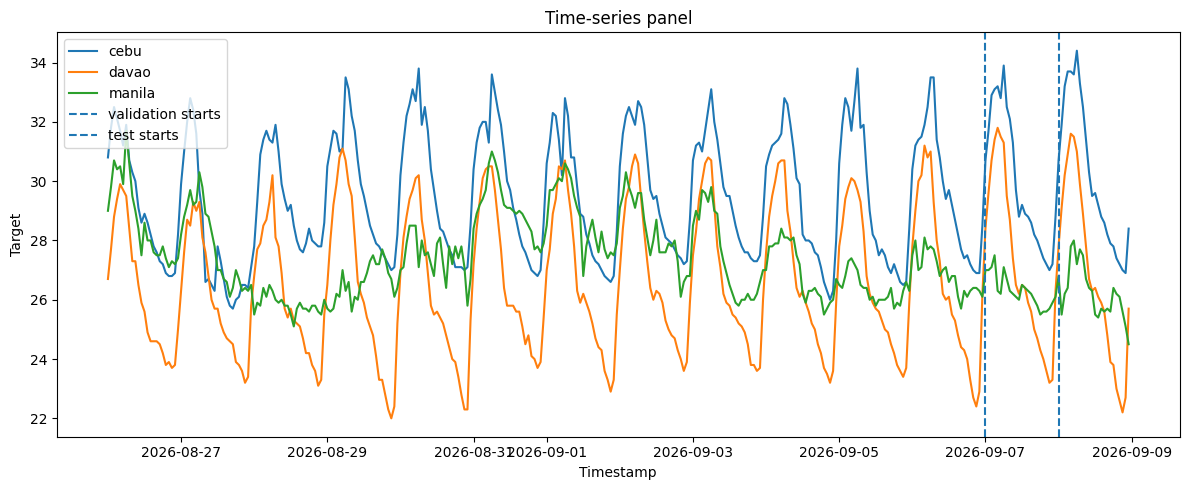

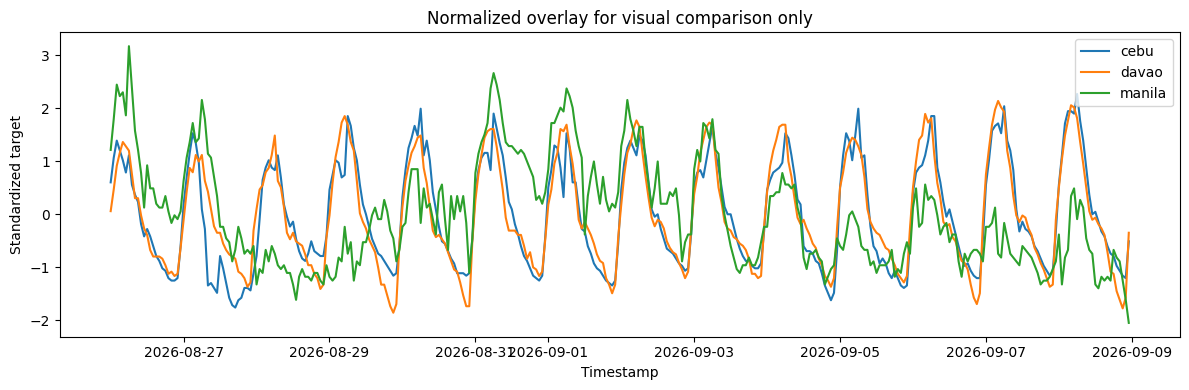

,count,mean,std,min,max
series_id,,,,,
cebu,336,29.502381,2.163385,25.7,34.4
davao,336,26.558036,2.458429,22.0,31.8
manila,336,27.327381,1.382263,24.5,31.7


In [6]:
# @title 4.1 Plot the series and the split boundaries
import matplotlib.pyplot as plt

val_start_index = panel["n_steps"] - VALIDATION_HORIZON - TEST_HORIZON
test_start_index = panel["n_steps"] - TEST_HORIZON

fig, ax = plt.subplots(figsize=(12, 5))
for sid in panel["series_ids"]:
    block = frame[frame["series_id"] == sid]
    ax.plot(block["timestamp"], block["target"], label=sid)
ax.axvline(panel["timestamps"][val_start_index], linestyle="--", label="validation starts")
ax.axvline(panel["timestamps"][test_start_index], linestyle="--", label="test starts")
ax.set_title("Time-series panel")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Target")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_ROOT / "figures" / "panel_overview.png", dpi=150, bbox_inches="tight")
plt.show()

# Normalize only for visualization; models receive raw target values.
fig, ax = plt.subplots(figsize=(12, 4))
for sid in panel["series_ids"]:
    block = frame[frame["series_id"] == sid].copy()
    values = block["target"].to_numpy(dtype=float)
    z = (values - values.mean()) / (values.std() or 1.0)
    ax.plot(block["timestamp"], z, label=sid)
ax.set_title("Normalized overlay for visual comparison only")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Standardized target")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_ROOT / "figures" / "normalized_overlay.png", dpi=150, bbox_inches="tight")
plt.show()

display(frame.groupby("series_id")["target"].agg(["count", "mean", "std", "min", "max"]))

## EDA checkpoint

Write brief answers before any model runs:

1. Does each series have a trend, a 24-hour cycle, or both?
2. How do the series differ in level and in the size of their daily swing?
3. Do the series peak at the same hour?
4. Which baseline do you expect to do better: repeating the last value, or repeating yesterday's same hour? Why?

**Your notes:**

- Trend:
- Daily cycle:
- Differences between series:
- Baseline prediction and reason:

<details>
<summary><b>Show a sample answer</b></summary>

**Synthetic sample**

1. Both. Each series rises steadily and swings up and down once every 24 hours.
2. `B` sits about 32 above `A` on average (means 160.7 and 128.6). Its swing is ±9 against ±6 for `A`, and it rises more slowly: about 2.9 per day against 4.3.
3. No. `B` runs 5 hours ahead of `A`, as the formulas say. The normalised overlay shows the shift.
4. Seasonal naive. The next 24 hours look like the last 24 hours plus a small rise, whereas repeating the last value ignores the whole daily cycle. Seasonal naive will still miss by exactly one day's rise: 4.32 for `A` and 2.88 for `B`.

**Open-Meteo sample**

1. A strong 24-hour cycle with no clear trend over two weeks. Weather adds day-to-day changes on top.
2. Cebu is warmest (mean 29.5 °C), then Manila (27.3 °C) and Davao (26.6 °C). Davao swings most, about 7 °C a day; Manila least, about 2 °C.
3. Nearly. All three peak around 03:00–06:00 UTC, which is early afternoon in the Philippines.
4. Seasonal naive, for the same reason. For Manila, with its small swing, the last value is also a fair guess.

</details>


# 5. Split the data, build the baselines and define the metrics

**Evaluation practice.**

## Two baselines

A forecasting model is useful only if it beats simple methods under the same conditions. This notebook uses two:

1. **Last value:** repeat the final observed value for all 24 hours: ŷ(t+h) = y(t). It answers: *is the model better than assuming the present level continues?*
2. **Seasonal naive:** repeat the same hour from the previous day: ŷ(t+h) = y(t+h−24). It answers: *is the model better than repeating yesterday's pattern?*

A sophisticated model can still be unnecessary if a simple seasonal baseline performs similarly or better.

> **Key term — baseline.** A simple reference method. A complex model adds value only if it beats sensible baselines on the same data and metrics.

## Metrics

All forecasts, baselines included, are scored by one evaluator in the notebook. The point forecast is q0.5, the model median.

**Mean absolute error (MAE).** The average size of the errors, in the data's own units. Lower is better.

$$\text{MAE} = \frac{1}{n}\sum |y - \hat y|$$

**Root mean squared error (RMSE).** Like MAE, but squaring first makes large misses count more. Lower is better.

$$\text{RMSE} = \sqrt{\frac{1}{n}\sum (y - \hat y)^2}$$

**Skill against seasonal naive.** How much of the seasonal-naive error a model removes, per series:

$$\text{skill} = 1 - \frac{\text{MAE}_\text{model}}{\text{MAE}_\text{seasonal naive}}$$

| Skill | Meaning |
|---:|---|
| above 0 | the model beats seasonal naive |
| 0 | same error |
| below 0 | seasonal naive does better |

**Coverage and interval width.** Coverage is the fraction of true values that fall inside the model's q0.1–q0.9 band. Width is the band's average size. Coverage and interval width must be interpreted together. High coverage alone can be obtained with uninformatively wide intervals.

**Pinball loss.** A score for a single quantile. For q0.9, a truth above the forecast costs 0.9 per unit and a truth below it costs 0.1 per unit, so the loss rewards a q0.9 that is exceeded about 10% of the time. Lower is better.

### A worked example

Suppose the true values for three hours are 20, 22 and 30, and a model's q0.5 forecasts are 21, 22 and 26. The absolute errors are 1, 0 and 4.

- MAE = (1 + 0 + 4) / 3 ≈ 1.67.
- RMSE = √((1 + 0 + 16) / 3) ≈ 2.38. The one large miss dominates.
- If seasonal naive had MAE 2.5 on the same hours, skill = 1 − 1.67 / 2.5 ≈ 0.33.
- If the model's q0.1–q0.9 bands contained the first two truths but not the third, coverage = 2/3.

### Reading the result tables

- `pooled_*` scores all rows together. It is dominated by series with large values, so it depends on scale.
- `macro_*` averages the per-series scores, giving each series equal weight.
- The baselines give a single value, not a range, so their coverage and width columns do not describe an interval. Compare coverage and width only between foundation models.

> **Key term — residual.** True value minus forecast for one hour. A positive residual means the forecast was too low.

The next cell cuts the data at the forecast origins, builds both baselines for the validation and test periods, and defines the metric functions. It prints the context length and horizon for each period.

**Predict first.** Which baseline will have lower validation MAE, and why? Write your prediction before the next cell; compare it with the baseline scores in the combined table in Section 7, after the foundation-model runs.


In [7]:
# @title 5.1 Split the data, build the baselines and define the metrics
def tail_context(block, end_index, max_context=COMMON_MAX_CONTEXT):
    start = max(0, end_index - max_context)
    return block.iloc[start:end_index].copy()

def split_stage(frame, stage):
    ids = panel["series_ids"]
    pieces_history, pieces_truth = [], []
    n = panel["n_steps"]
    if stage == "validation":
        truth_start = n - TEST_HORIZON - VALIDATION_HORIZON
        truth_horizon = VALIDATION_HORIZON
    elif stage == "test":
        truth_start = n - TEST_HORIZON
        truth_horizon = TEST_HORIZON
    elif stage == "future":
        truth_start = n
        truth_horizon = TEST_HORIZON
    else:
        raise ValueError(stage)

    for sid in ids:
        block = frame[frame["series_id"] == sid].sort_values("timestamp").reset_index(drop=True)
        hist = tail_context(block, truth_start)
        if len(hist) < COMMON_MIN_CONTEXT:
            raise ValueError(f"{stage}/{sid}: context shorter than {COMMON_MIN_CONTEXT}")
        pieces_history.append(hist)
        if stage != "future":
            pieces_truth.append(block.iloc[truth_start:truth_start + truth_horizon].copy())

    history = pd.concat(pieces_history, ignore_index=True)
    truth = pd.concat(pieces_truth, ignore_index=True) if pieces_truth else None
    return history, truth, truth_horizon

validation_history, validation_truth, _ = split_stage(frame, "validation")
test_history, test_truth, _ = split_stage(frame, "test")
future_history, _, future_horizon = split_stage(frame, "future")

for name, hist, truth in (
    ("validation", validation_history, validation_truth),
    ("test", test_history, test_truth),
):
    for sid in panel["series_ids"]:
        h = hist[hist["series_id"] == sid]
        t = truth[truth["series_id"] == sid]
        assert h["timestamp"].max() < t["timestamp"].min(), f"{name}/{sid}: leakage"

validation_history.to_csv(WORK_ROOT / "requests" / "validation_history.csv", index=False)
test_history.to_csv(WORK_ROOT / "requests" / "test_history.csv", index=False)
future_history.to_csv(WORK_ROOT / "requests" / "future_history.csv", index=False)

def mae(y, p):
    y, p = np.asarray(y, float), np.asarray(p, float)
    return float(np.mean(np.abs(y - p)))

def rmse(y, p):
    y, p = np.asarray(y, float), np.asarray(p, float)
    return float(np.sqrt(np.mean((y - p) ** 2)))

def pinball_loss(y, qhat, q):
    y, qhat = np.asarray(y, float), np.asarray(qhat, float)
    error = y - qhat
    return float(np.mean(np.maximum(q * error, (q - 1.0) * error)))

def baseline_forecast(history, truth, kind, season_length=SEASON_LENGTH):
    rows = []
    for sid in panel["series_ids"]:
        h = history[history["series_id"] == sid].sort_values("timestamp")
        t = truth[truth["series_id"] == sid].sort_values("timestamp")
        values = h["target"].to_numpy(dtype=float)
        if kind == "last_value":
            pred = np.repeat(values[-1], len(t))
        elif kind == "seasonal_naive":
            if len(values) < season_length:
                raise ValueError(
                    f"{sid}: seasonal baseline needs at least {season_length} historical observations"
                )
            repeats = []
            for step in range(len(t)):
                repeats.append(values[-season_length + (step % season_length)])
            pred = np.asarray(repeats, dtype=float)
        else:
            raise ValueError(kind)
        for step, ((_, truth_row), forecast) in enumerate(zip(t.iterrows(), pred), start=1):
            rows.append({
                "model": kind,
                "series_id": sid,
                "timestamp": truth_row["timestamp"],
                "step": step,
                "prediction": float(forecast),
                "q0.1": float(forecast),
                "q0.5": float(forecast),
                "q0.9": float(forecast),
            })
    return pd.DataFrame(rows)

def evaluate_forecasts(forecasts, truth, seasonal_baseline):
    truth_key = truth[["series_id", "timestamp", "target"]].rename(columns={"target": "truth"})
    # Several models share each (series, timestamp), so the key is unique per model, not overall.
    duplicated = forecasts.duplicated(["model", "series_id", "timestamp"])
    if duplicated.any():
        raise ValueError(f"Duplicate forecast rows per model/series/timestamp: {int(duplicated.sum())}")
    merged = forecasts.merge(truth_key, on=["series_id", "timestamp"], how="left", validate="many_to_one")
    if merged["truth"].isna().any():
        raise ValueError("Forecast rows do not align exactly to held-out truth")

    seasonal = seasonal_baseline.merge(
        truth_key, on=["series_id", "timestamp"], how="left", validate="one_to_one"
    )
    seasonal_mae_by_series = {
        sid: mae(block["truth"], block["prediction"])
        for sid, block in seasonal.groupby("series_id")
    }

    per_series = []
    for (model, sid), block in merged.groupby(["model", "series_id"], sort=False):
        model_mae = mae(block["truth"], block["prediction"])
        seasonal_mae = seasonal_mae_by_series[sid]
        per_series.append({
            "model": model,
            "series_id": sid,
            "mae": model_mae,
            "rmse": rmse(block["truth"], block["prediction"]),
            "seasonal_naive_mae": seasonal_mae,
            "mae_skill_vs_seasonal": (
                1.0 - model_mae / seasonal_mae if seasonal_mae > 0 else None
            ),
            "pinball_q0.1": pinball_loss(block["truth"], block["q0.1"], 0.1),
            "pinball_q0.5": pinball_loss(block["truth"], block["q0.5"], 0.5),
            "pinball_q0.9": pinball_loss(block["truth"], block["q0.9"], 0.9),
            "q10_q90_coverage": float(
                np.mean(
                    (block["truth"].to_numpy() >= block["q0.1"].to_numpy())
                    & (block["truth"].to_numpy() <= block["q0.9"].to_numpy())
                )
            ),
            "mean_interval_width": float(
                np.mean(block["q0.9"].to_numpy() - block["q0.1"].to_numpy())
            ),
        })
    per_series = pd.DataFrame(per_series)

    aggregate_rows = []
    for model, block in merged.groupby("model", sort=False):
        ps = per_series[per_series["model"] == model]
        aggregate_rows.append({
            "model": model,
            "pooled_mae": mae(block["truth"], block["prediction"]),
            "pooled_rmse": rmse(block["truth"], block["prediction"]),
            "macro_mae": float(ps["mae"].mean()),
            "macro_rmse": float(ps["rmse"].mean()),
            "macro_mae_skill_vs_seasonal": float(ps["mae_skill_vs_seasonal"].mean()),
            "q10_q90_coverage": float(
                np.mean(
                    (block["truth"].to_numpy() >= block["q0.1"].to_numpy())
                    & (block["truth"].to_numpy() <= block["q0.9"].to_numpy())
                )
            ),
            "mean_interval_width": float(
                np.mean(block["q0.9"].to_numpy() - block["q0.1"].to_numpy())
            ),
            "pinball_q0.1": pinball_loss(block["truth"], block["q0.1"], 0.1),
            "pinball_q0.5": pinball_loss(block["truth"], block["q0.5"], 0.5),
            "pinball_q0.9": pinball_loss(block["truth"], block["q0.9"], 0.9),
        })
    return merged, per_series, pd.DataFrame(aggregate_rows)

validation_last = baseline_forecast(validation_history, validation_truth, "last_value")
validation_seasonal = baseline_forecast(validation_history, validation_truth, "seasonal_naive")
test_last = baseline_forecast(test_history, test_truth, "last_value")
test_seasonal = baseline_forecast(test_history, test_truth, "seasonal_naive")

validation_last.to_csv(OUTPUT_ROOT / "validation" / "last_value.csv", index=False)
validation_seasonal.to_csv(OUTPUT_ROOT / "validation" / "seasonal_naive.csv", index=False)
test_last.to_csv(OUTPUT_ROOT / "test" / "last_value.csv", index=False)
test_seasonal.to_csv(OUTPUT_ROOT / "test" / "seasonal_naive.csv", index=False)

print({
    "validation_context_steps": len(validation_history) // panel["n_series"],
    "validation_horizon": VALIDATION_HORIZON,
    "test_context_steps": len(test_history) // panel["n_series"],
    "test_horizon": TEST_HORIZON,
})

{'validation_context_steps': 288, 'validation_horizon': 24, 'test_context_steps': 312, 'test_horizon': 24}


### Expected result

For the synthetic sample: validation context 48 hours, test context 72 hours, both horizons 24. For the Open-Meteo sample: validation context 288 hours and test context 312 hours.

## Baseline checkpoint

Before running any foundation model:

1. Which baseline should perform better on the synthetic sample: last value or the 24-hour seasonal naive? Explain why.
2. Why can seasonal naive never be perfect on the synthetic sample?
3. What would a skill of 0.5 mean in words?

<details>
<summary><b>Show a sample answer</b></summary>

1. Seasonal naive. The synthetic series repeat a 24-hour pattern, so yesterday's same hour is close to today's. Repeating the last value ignores the pattern. In the reference run, last value scored macro MAE 5.53 against 3.60 for seasonal naive on both periods.
2. Each series also rises steadily. Yesterday's value is always one day's rise too low: 0.18 × 24 = 4.32 for `A` and 0.12 × 24 = 2.88 for `B`. Those are exactly the seasonal-naive MAEs.
3. The model's MAE is half the seasonal-naive MAE for that series: it removes half the error of repeating yesterday.

</details>


# 6. Prepare the model environments

**Infrastructure.**

**You can run the cells in this section without reading their code.**

The models need different, incompatible versions of PyTorch and other packages. Installing them all into the notebook's own Python would break it, or break one model to satisfy another. The next cell therefore creates one **virtual environment** per selected model, each on Python 3.12, and installs that model's exact package versions into it.

> **Key term — virtual environment.** A separate folder of installed Python packages, so that one model's requirements cannot break another's or the notebook's.

The first run takes several minutes per model. Later runs in the same Colab session reuse the environments.


In [8]:
# @title 6.1 Build one environment per model
import os
import subprocess
import sys
from pathlib import Path

# Model environments are pinned to Python 3.12 regardless of the notebook kernel
# (Colab moved to Python 3.13). uv provisions a standalone CPython 3.12 when the
# runtime does not have one.
MODEL_ENV_PYTHON = "3.12"
UV_PIN = "uv==0.8.17"

def ensure_uv():
    try:
        subprocess.run([sys.executable, "-m", "uv", "--version"], check=True, capture_output=True)
    except (subprocess.CalledProcessError, FileNotFoundError):
        subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", UV_PIN], check=True)

ENV_PINS = {
    "tirex": [
        "tirex-2==0.2.1",
        "torch==2.8.0",
        "torchvision==0.23.0",
        "torchaudio==2.8.0",
        # xLSTM's flashrnn dependency leaves triton unpinned; torch 2.8.0 needs 3.4.0.
        "triton==3.4.0",
        "huggingface-hub==0.36.2",
        "numpy==2.3.3",
        "pandas==2.3.3",
    ],
    "chronos": [
        "chronos-forecasting==2.3.1",
        "transformers==4.57.6",
        "huggingface-hub==0.36.2",
        "numpy==2.5.3",
        "pandas==3.0.5",
        "torch==2.14.0",
        "torchvision==0.29.0",
        "torchaudio==2.11.0",
    ],
    "toto": [
        "toto-2==2.0.0",
        "torch==2.7.0",
        "torchaudio==2.7.0",
        "torchvision==0.22.0",
        "huggingface-hub==0.36.2",
        "transformers==4.57.6",
        "numpy==1.26.4",
        "pandas==2.2.3",
    ],
}

def env_python(name):
    root = WORK_ROOT / "envs" / name
    if os.name == "nt":
        return root / "Scripts" / "python.exe"
    return root / "bin" / "python"

def ensure_environment(name):
    root = WORK_ROOT / "envs" / name
    python = env_python(name)
    marker = root / ".dimer_workshop_ready"
    signature = "\n".join([f"python=={MODEL_ENV_PYTHON}", *ENV_PINS[name]])
    sig = __import__("hashlib").sha256(signature.encode()).hexdigest()
    if marker.is_file() and marker.read_text().strip() == sig and python.is_file():
        print(f"{name}: existing pinned environment reused")
        return python

    if root.exists():
        import shutil
        shutil.rmtree(root)
    subprocess.run(
        [sys.executable, "-m", "uv", "venv", "--seed", "--python", MODEL_ENV_PYTHON, str(root)],
        check=True,
    )
    subprocess.run(
        [str(python), "-m", "pip", "install", "--quiet", "--upgrade", "pip"],
        check=True,
    )
    subprocess.run(
        [str(python), "-m", "pip", "install", "--quiet", *ENV_PINS[name]],
        check=True,
    )
    marker.write_text(sig, encoding="utf-8")
    print(f"{name}: environment ready")
    return python

ensure_uv()
MODEL_PYTHONS = {name: ensure_environment(name) for name in SELECTED_MODELS}
print({k: str(v) for k, v in MODEL_PYTHONS.items()})

tirex: environment ready
chronos: environment ready
{'tirex': 'work/envs/tirex/bin/python', 'chronos': 'work/envs/chronos/bin/python'}


### Expected result

One line per model ending in `environment ready` (or `existing pinned environment reused` on a rerun), then the path to each environment's Python.

## 6.2 The model runner programs

The next cell writes one small program per model into the session folder. Each program:

- downloads only the pinned checkpoint files and checks their size and SHA-256;
- loads the model through its own upstream package;
- forecasts from the history it is given, with no training;
- converts the output to the common q0.1 / q0.5 / q0.9 table and checks that the point forecast equals q0.5; and
- records load time, forecast time and device.

TiRex-2 runs on the CPU: its runner hides the GPU, because its pinned software tries to compile GPU code when a GPU is visible. The programs do not download or import any DIMER code.

> **Key term — model checkpoint.** The file of trained weights that defines a pretrained model.


In [9]:
# @title 6.2 Write the model runner programs
import hashlib
from pathlib import Path

TIREX_RUNNER = r"""
import argparse, hashlib, json, platform, time
from pathlib import Path
import numpy as np
import pandas as pd

MODEL_ID="NX-AI/TiRex-2"
REVISION="05e5b26db52bfb256f1ae1bdf785589850482de3"
FILES={
 "README.md":(5521,"ec10f277ff820fb8915b4ff3988916c25bc892167902aba84bb9bfe24d190b70"),
 "model-config.yaml":(1204,"cddbe6d0be4919cb7b0cad747fb19a295264e129d1c0790cf62133b4cb5da727"),
 "model.ckpt":(380613375,"184b160ffbe4c01a26beeba14015ff3507c7497e1f3577114187bbc1d19fcac1"),
}
LEVELS=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]

def sha(path):
    h=hashlib.sha256()
    with open(path,"rb") as f:
        for chunk in iter(lambda:f.read(1<<20),b""): h.update(chunk)
    return h.hexdigest()

def stage(root):
    from huggingface_hub import hf_hub_download
    root.mkdir(parents=True,exist_ok=True)
    for name,(size,digest) in FILES.items():
        p=Path(hf_hub_download(MODEL_ID,name,revision=REVISION,local_dir=str(root)))
        if p.stat().st_size!=size or sha(p)!=digest:
            raise ValueError(f"{name}: integrity mismatch")
    return root

def main():
    ap=argparse.ArgumentParser()
    ap.add_argument("--input",required=True)
    ap.add_argument("--output",required=True)
    ap.add_argument("--metadata",required=True)
    ap.add_argument("--cache",required=True)
    ap.add_argument("--horizon",type=int,required=True)
    ap.add_argument("--partition",required=True)
    args=ap.parse_args()

    frame=pd.read_csv(args.input,parse_dates=["timestamp"])
    ids=list(frame["series_id"].astype(str).drop_duplicates())
    arrays=[]
    for sid in ids:
        block=frame[frame["series_id"].astype(str)==sid].sort_values("timestamp")
        arrays.append(block["target"].to_numpy(dtype=np.float32))
    lengths={len(x) for x in arrays}
    if len(lengths)!=1: raise ValueError("all series must have equal context length")
    values=np.stack(arrays)

    started=time.perf_counter()
    root=stage(Path(args.cache))
    from tirex2 import load_model, TimeseriesType
    import torch
    model=load_model(str(root),device="cpu")
    load_seconds=time.perf_counter()-started

    started=time.perf_counter()
    ts=TimeseriesType(target=torch.from_numpy(values),past_covariates=None,future_covariates=None)
    q=np.asarray(model.forecast([ts],prediction_length=args.horizon,output_type="numpy")[0],dtype=float)
    inference_seconds=time.perf_counter()-started
    expected=(len(ids),len(LEVELS),args.horizon)
    if q.shape!=expected: raise RuntimeError(f"unexpected shape {q.shape}, expected {expected}")

    delta=frame.sort_values("timestamp")["timestamp"].drop_duplicates().diff().dropna().iloc[0]
    origins={sid:frame[frame["series_id"].astype(str)==sid]["timestamp"].max() for sid in ids}
    rows=[]
    for i,sid in enumerate(ids):
        for step in range(args.horizon):
            rows.append({
                "model":"TiRex-2","partition":args.partition,
                "forecast_origin":origins[sid],
                "series_id":sid,"timestamp":origins[sid]+delta*(step+1),"step":step+1,
                "q0.1":q[i,0,step],"q0.5":q[i,4,step],"q0.9":q[i,8,step],
                "prediction":q[i,4,step],
            })
    out=pd.DataFrame(rows)
    if not np.allclose(out["prediction"],out["q0.5"],rtol=0,atol=0):
        raise RuntimeError("TiRex normalized prediction != q0.5")
    out.to_csv(args.output,index=False)
    Path(args.metadata).write_text(json.dumps({
        "model":"TiRex-2","model_id":MODEL_ID,"revision":REVISION,"device":"cpu",
        "context_length":int(values.shape[1]),"horizon":args.horizon,
        "load_seconds":load_seconds,"inference_seconds":inference_seconds,
        "weight_bytes":FILES["model.ckpt"][0],"python":platform.python_version()
    },indent=2),encoding="utf-8")

if __name__=="__main__": main()
"""

CHRONOS_RUNNER = r"""
import argparse, hashlib, json, platform, time
from pathlib import Path
import numpy as np
import pandas as pd

MODEL_ID="amazon/chronos-2"
REVISION="95a9710e2596287d08352589f42634fa5abdf0a7"
FILES={
 "README.md":(31,"4bcf87ecfbbb8e07a01b21415a970c8b53a5283bf6872b657040d3f45c9241f7"),
 "config.json":(1067,"ef1143bfdc9c0376d9a056eefca46cb4b1ec3d0ffacd541ff56feb40fb708031"),
 "model.safetensors":(477930472,"ddcda3c7508bf2528087723e98a20707cc04b7f370ae275a9fd88078ddba4f42"),
}

def sha(path):
    h=hashlib.sha256()
    with open(path,"rb") as f:
        for chunk in iter(lambda:f.read(1<<20),b""): h.update(chunk)
    return h.hexdigest()

def stage(root):
    from huggingface_hub import hf_hub_download
    root.mkdir(parents=True,exist_ok=True)
    for name,(size,digest) in FILES.items():
        p=Path(hf_hub_download(MODEL_ID,name,revision=REVISION,local_dir=str(root)))
        if p.stat().st_size!=size or sha(p)!=digest:
            raise ValueError(f"{name}: integrity mismatch")
    refused=list(root.glob("*.bin"))+list(root.glob("*.pt"))+list(root.glob("*.pth"))+list(root.glob("*.ckpt"))
    if refused: raise ValueError(f"refused pickle-style model files present: {refused}")
    return root

def main():
    ap=argparse.ArgumentParser()
    ap.add_argument("--input",required=True)
    ap.add_argument("--output",required=True)
    ap.add_argument("--metadata",required=True)
    ap.add_argument("--cache",required=True)
    ap.add_argument("--horizon",type=int,required=True)
    ap.add_argument("--partition",required=True)
    ap.add_argument("--freq",required=True)
    args=ap.parse_args()

    frame=pd.read_csv(args.input,parse_dates=["timestamp"])
    frame["series_id"]=frame["series_id"].astype(str)

    started=time.perf_counter()
    root=stage(Path(args.cache))
    import torch
    from chronos import BaseChronosPipeline
    device="cuda" if torch.cuda.is_available() else "cpu"
    pipe=BaseChronosPipeline.from_pretrained(str(root),device_map=device,dtype="auto")
    load_seconds=time.perf_counter()-started

    started=time.perf_counter()
    raw=pipe.predict_df(
        frame,
        future_df=None,
        id_column="series_id",
        timestamp_column="timestamp",
        target=["target"],
        prediction_length=args.horizon,
        quantile_levels=[0.1,0.5,0.9],
        batch_size=256,
        context_length=None,
        cross_learning=False,
        validate_inputs=True,
        freq=args.freq,
    )
    inference_seconds=time.perf_counter()-started

    required=["series_id","timestamp","target_name","predictions","0.1","0.5","0.9"]
    missing=[c for c in required if c not in raw.columns]
    if missing: raise RuntimeError(f"Chronos raw output missing {missing}; got {list(raw.columns)}")
    if set(raw["target_name"].astype(str))!={"target"}:
        raise RuntimeError("unexpected target_name values")
    out=raw.rename(columns={
        "predictions":"prediction","0.1":"q0.1","0.5":"q0.5","0.9":"q0.9"
    })[["series_id","timestamp","prediction","q0.1","q0.5","q0.9"]].copy()
    out["series_id"]=out["series_id"].astype(str)
    out["timestamp"]=pd.to_datetime(out["timestamp"])
    out["step"]=out.groupby("series_id",sort=False).cumcount()+1
    origins=frame.groupby("series_id")["timestamp"].max().to_dict()
    out["forecast_origin"]=out["series_id"].map(origins)
    out["model"]="Chronos-2"
    out["partition"]=args.partition
    out=out[["model","partition","forecast_origin","series_id","timestamp","step","q0.1","q0.5","q0.9","prediction"]]
    if not np.allclose(out["prediction"],out["q0.5"],rtol=0,atol=1e-6):
        raise RuntimeError("Chronos normalized prediction != q0.5")
    out.to_csv(args.output,index=False)
    Path(args.metadata).write_text(json.dumps({
        "model":"Chronos-2","model_id":MODEL_ID,"revision":REVISION,"device":device,
        "context_length":int(frame.groupby("series_id").size().max()),"horizon":args.horizon,
        "load_seconds":load_seconds,"inference_seconds":inference_seconds,
        "weight_bytes":FILES["model.safetensors"][0],"python":platform.python_version()
    },indent=2),encoding="utf-8")

if __name__=="__main__": main()
"""

TOTO_RUNNER = r"""
import argparse, hashlib, json, platform, time
from pathlib import Path
import numpy as np
import pandas as pd

MODEL_ID="Datadog/Toto-2.0-2.5B"
REVISION="51a2812bbe449437c01b79c0e425ed578f335f5b"
FILES={
 "README.md":(7188,"5cd75f3d08d1574c085ee31a2886855d82247f76cb3bd0b8015750a7fc1d316d"),
 "config.json":(598,"172904c65bb5af77a95e1a81cdd9214f4c9d983651d6dceef1375d3d09f47a36"),
 "model.safetensors":(9817176960,"dc08942b20751ac906167194d4ca4aa06b4367e80aabe5f1d5153b30b874bdb9"),
}
LEVELS=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]

def sha(path):
    h=hashlib.sha256()
    with open(path,"rb") as f:
        for chunk in iter(lambda:f.read(1<<20),b""): h.update(chunk)
    return h.hexdigest()

def stage(root):
    from huggingface_hub import hf_hub_download
    root.mkdir(parents=True,exist_ok=True)
    for name,(size,digest) in FILES.items():
        p=Path(hf_hub_download(MODEL_ID,name,revision=REVISION,local_dir=str(root)))
        if p.stat().st_size!=size or sha(p)!=digest:
            raise ValueError(f"{name}: integrity mismatch")
    return root

def main():
    ap=argparse.ArgumentParser()
    ap.add_argument("--input",required=True)
    ap.add_argument("--output",required=True)
    ap.add_argument("--metadata",required=True)
    ap.add_argument("--cache",required=True)
    ap.add_argument("--horizon",type=int,required=True)
    ap.add_argument("--partition",required=True)
    args=ap.parse_args()

    frame=pd.read_csv(args.input,parse_dates=["timestamp"])
    frame["series_id"]=frame["series_id"].astype(str)
    ids=list(frame["series_id"].drop_duplicates())
    arrays=[]
    for sid in ids:
        block=frame[frame["series_id"]==sid].sort_values("timestamp")
        arrays.append(block["target"].to_numpy(dtype=np.float32))
    if len({len(x) for x in arrays})!=1: raise ValueError("all series need equal context")
    values=np.stack(arrays)

    started=time.perf_counter()
    root=stage(Path(args.cache))
    import torch
    if not torch.cuda.is_available():
        raise RuntimeError("Toto FULL tier requires a CUDA GPU")
    from toto2 import Toto2Model
    model=Toto2Model.from_pretrained(str(root),map_location="cpu").to("cuda").eval()
    load_seconds=time.perf_counter()-started

    patch_size=int(model.config.patch_size)
    if values.shape[1] < patch_size:
        raise ValueError(f"context shorter than patch size {patch_size}")
    padding=(patch_size-values.shape[1]%patch_size)%patch_size
    target=torch.as_tensor(values,dtype=torch.float32,device="cuda").unsqueeze(0)
    mask=torch.ones_like(target,dtype=torch.bool)
    if padding:
        target=torch.nn.functional.pad(target,(padding,0),value=0.0)
        mask=torch.nn.functional.pad(mask,(padding,0),value=False)
    series_ids=torch.arange(values.shape[0],device="cuda",dtype=torch.long).unsqueeze(0)

    started=time.perf_counter()
    with torch.inference_mode():
        forecast=model.forecast(
            {"target":target,"target_mask":mask,"series_ids":series_ids},
            horizon=args.horizon,
            decode_block_size=768,
            has_missing_values=padding>0,
        )
    inference_seconds=time.perf_counter()-started
    q=np.asarray(forecast.detach().cpu(),dtype=float)
    expected=(len(LEVELS),1,len(ids),args.horizon)
    if q.shape!=expected: raise RuntimeError(f"unexpected shape {q.shape}; expected {expected}")
    q=np.transpose(q[:,0,:,:],(1,0,2))

    delta=frame.sort_values("timestamp")["timestamp"].drop_duplicates().diff().dropna().iloc[0]
    origins={sid:frame[frame["series_id"]==sid]["timestamp"].max() for sid in ids}
    rows=[]
    for i,sid in enumerate(ids):
        for step in range(args.horizon):
            rows.append({
                "model":"Toto 2.0 2.5B","partition":args.partition,
                "forecast_origin":origins[sid],
                "series_id":sid,"timestamp":origins[sid]+delta*(step+1),"step":step+1,
                "q0.1":q[i,0,step],"q0.5":q[i,4,step],"q0.9":q[i,8,step],
                "prediction":q[i,4,step],
            })
    out=pd.DataFrame(rows)
    if not np.allclose(out["prediction"],out["q0.5"],rtol=0,atol=0):
        raise RuntimeError("Toto normalized prediction != q0.5")
    out.to_csv(args.output,index=False)
    Path(args.metadata).write_text(json.dumps({
        "model":"Toto 2.0 2.5B","model_id":MODEL_ID,"revision":REVISION,"device":"cuda",
        "context_length":int(values.shape[1]),"context_padding":int(padding),
        "patch_size":patch_size,"horizon":args.horizon,"decode_block_size":768,
        "load_seconds":load_seconds,"inference_seconds":inference_seconds,
        "weight_bytes":FILES["model.safetensors"][0],"python":platform.python_version()
    },indent=2),encoding="utf-8")

if __name__=="__main__": main()
"""

RUNNERS = {"tirex": TIREX_RUNNER, "chronos": CHRONOS_RUNNER, "toto": TOTO_RUNNER}

for name, source in RUNNERS.items():
    path = WORK_ROOT / "runners" / f"{name}_runner.py"
    path.write_text(source, encoding="utf-8")
    compile(source, str(path), "exec")
    print(name, path, hashlib.sha256(source.encode()).hexdigest()[:16] + "…")

tirex work/runners/tirex_runner.py 386c470d6e4ebcdd…
chronos work/runners/chronos_runner.py 7782bda512ae1f58…
toto work/runners/toto_runner.py 0f7bdc59d0ca5c56…


# 7. Forecast the validation period

**Evaluation practice.**

Every selected model now receives only the validation context and forecasts the validation period. The validation truth is used only afterwards, to score the forecasts. The first run downloads each checkpoint, so it is slower than later runs.

The cell then shows two tables: one row per model with the macro and pooled scores, then one row per model and series.

**Predict first.** Will either foundation model beat seasonal naive on every series? Will the narrower q10–q90 band also have better coverage? Write your prediction and reason before running this comparison.


In [10]:
# @title 7.1 Forecast the validation period with each model
import json
import os
import subprocess
import time

def run_model(name, stage, input_path, horizon):
    python = MODEL_PYTHONS[name]
    runner = WORK_ROOT / "runners" / f"{name}_runner.py"
    output = OUTPUT_ROOT / stage / f"{name}.csv"
    metadata = WORK_ROOT / "run_metadata" / f"{stage}_{name}.json"
    cache = WORK_ROOT / "model_cache" / name
    cmd = [
        str(python), str(runner),
        "--input", str(input_path),
        "--output", str(output),
        "--metadata", str(metadata),
        "--cache", str(cache),
        "--horizon", str(horizon),
        "--partition", stage,
    ]
    if name == "chronos":
        cmd += ["--freq", panel["frequency_alias"]]

    env = os.environ.copy()
    # Colab sets MPLBACKEND to its inline backend, which the model environments do not have.
    # Toto's imports load matplotlib, so give the runners a plain non-interactive backend.
    env["MPLBACKEND"] = "Agg"
    if name == "tirex":
        # Avoid upstream xLSTM's CUDA-toolchain import path on GPU hosts.
        env["CUDA_VISIBLE_DEVICES"] = ""

    started = time.perf_counter()
    completed = subprocess.run(cmd, check=False, env=env, text=True, capture_output=True)
    if completed.returncode != 0:
        raise RuntimeError(
            f"{name} {stage} run failed (exit {completed.returncode}).\n"
            f"--- stderr (tail) ---\n{completed.stderr[-4000:]}\n"
            f"--- stdout (tail) ---\n{completed.stdout[-1000:]}"
        )
    wall_seconds = time.perf_counter() - started
    if completed.stdout.strip():
        print(f"[{name}] {completed.stdout[-1200:]}")
    meta = json.loads(metadata.read_text(encoding="utf-8"))
    meta["wall_seconds"] = wall_seconds
    metadata.write_text(json.dumps(meta, indent=2), encoding="utf-8")
    return pd.read_csv(output, parse_dates=["timestamp", "forecast_origin"]), meta

validation_model_frames = []
validation_runtime = {}
for name in SELECTED_MODELS:
    print("validation:", name)
    forecast_frame, meta = run_model(
        name, "validation", WORK_ROOT / "requests" / "validation_history.csv", VALIDATION_HORIZON
    )
    validation_model_frames.append(forecast_frame)
    validation_runtime[name] = meta

validation_models = pd.concat(validation_model_frames, ignore_index=True)
validation_all = pd.concat(
    [validation_models, validation_last, validation_seasonal],
    ignore_index=True,
)

validation_scored, validation_per_series, validation_aggregate = evaluate_forecasts(
    validation_all, validation_truth, validation_seasonal
)

validation_scored.to_csv(OUTPUT_ROOT / "validation" / "forecasts_with_truth.csv", index=False)
validation_per_series.to_csv(OUTPUT_ROOT / "validation" / "per_series_metrics.csv", index=False)
validation_aggregate.to_csv(OUTPUT_ROOT / "validation" / "aggregate_metrics.csv", index=False)
(OUTPUT_ROOT / "validation" / "runtime.json").write_text(
    json.dumps(validation_runtime, indent=2), encoding="utf-8"
)

display(validation_aggregate)
display(validation_per_series)

validation: tirex
validation: chronos


,model,pooled_mae,pooled_rmse,macro_mae,macro_rmse,macro_mae_skill_vs_seasonal,q10_q90_coverage,mean_interval_width,pinball_q0.1,pinball_q0.5,pinball_q0.9
0,TiRex-2,0.555648,0.690540,0.555648,0.679140,0.045631,0.736111,1.709542,0.112565,0.277824,0.138795
1,Chronos-2,0.502698,0.631795,0.502698,0.628037,0.129886,0.652778,1.392949,0.091899,0.251349,0.147999
2,last_value,1.594444,2.311084,1.594444,2.053212,-1.918070,0.041667,0.000000,0.445000,0.797222,1.149444
3,seasonal_naive,0.576389,0.690712,0.576389,0.687015,0.000000,0.013889,0.000000,0.252083,0.288194,0.324306


,model,series_id,mae,rmse,seasonal_naive_mae,mae_skill_vs_seasonal,pinball_q0.1,pinball_q0.5,pinball_q0.9,q10_q90_coverage,mean_interval_width
0,TiRex-2,cebu,0.448778,0.573330,0.529167,0.151915,0.130512,0.224389,0.098511,0.833333,1.765840
1,TiRex-2,davao,0.503820,0.609468,0.545833,0.076971,0.114365,0.251910,0.133962,0.583333,1.250537
2,TiRex-2,manila,0.714344,0.854621,0.654167,-0.091991,0.092818,0.357172,0.183912,0.791667,2.112248
3,Chronos-2,cebu,0.450233,0.552436,0.529167,0.149166,0.105140,0.225116,0.117081,0.583333,1.176529
4,Chronos-2,davao,0.469337,0.612792,0.545833,0.140146,0.096573,0.234669,0.159332,0.583333,1.041543
5,Chronos-2,manila,0.588523,0.718884,0.654167,0.100347,0.073985,0.294262,0.167583,0.791667,1.960773
6,last_value,cebu,2.054167,2.679630,0.529167,-2.881890,0.432083,1.027083,1.622083,0.000000,0.000000
7,last_value,davao,2.308333,2.920616,0.545833,-3.229008,0.770833,1.154167,1.537500,0.041667,0.000000
8,last_value,manila,0.420833,0.559390,0.654167,0.356688,0.132083,0.210417,0.288750,0.083333,0.000000
9,seasonal_naive,cebu,0.529167,0.668019,0.529167,0.000000,0.142917,0.264583,0.386250,0.000000,0.000000


### Read the validation results carefully

The most important comparison is not which model has the smallest pooled MAE. Look at:

- each individual series, not only the average;
- seasonal-naive performance, and the skill column;
- q10–q90 coverage together with interval width; and
- resource cost, which Section 10 measures.

A negative skill means the model produced **more error than simply repeating the previous 24-hour pattern**.

The next cell plots the history, the truth, both baselines and every model's median for the first series, then each model's q10–q90 band.


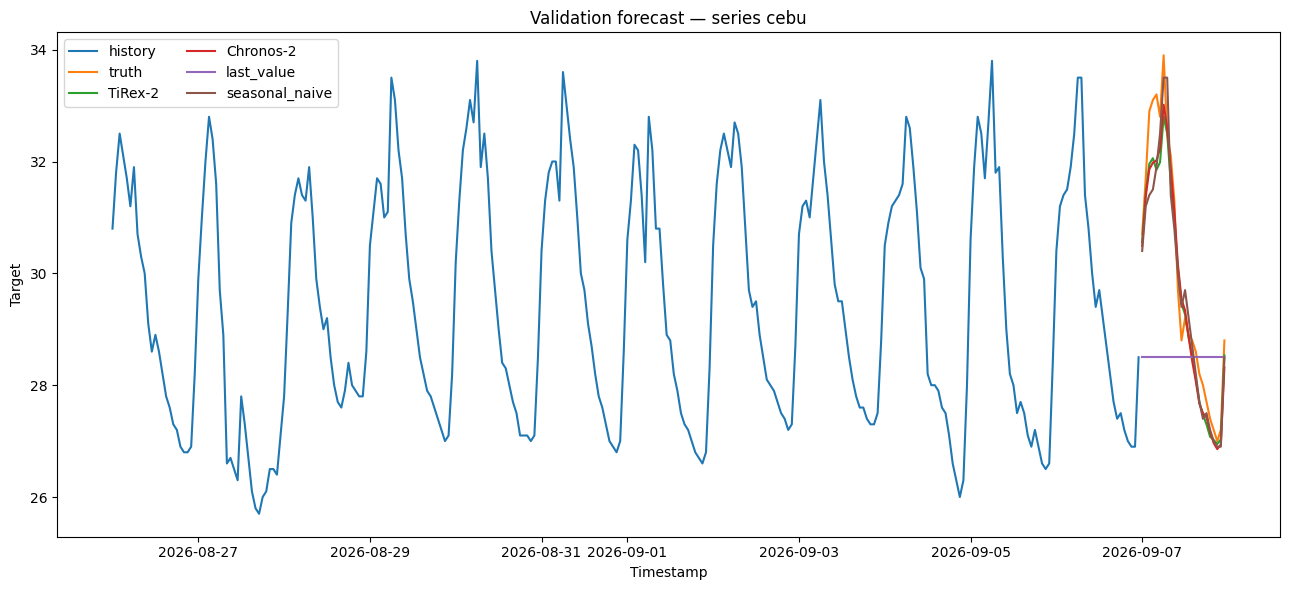

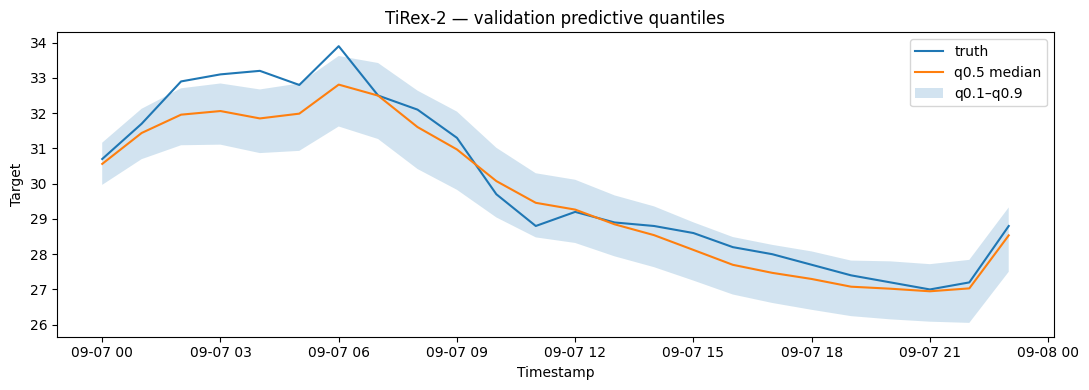

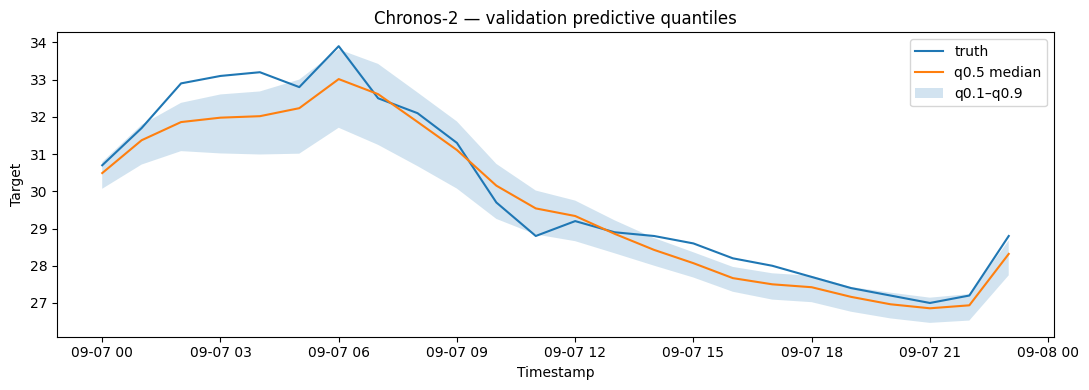

In [11]:
# @title 7.2 Plot the validation forecasts
PLOT_SERIES = panel["series_ids"][0]

history_plot = validation_history[validation_history["series_id"] == PLOT_SERIES]
truth_plot = validation_truth[validation_truth["series_id"] == PLOT_SERIES]
forecast_plot = validation_all[validation_all["series_id"] == PLOT_SERIES]

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(history_plot["timestamp"], history_plot["target"], label="history")
ax.plot(truth_plot["timestamp"], truth_plot["target"], label="truth")
for model, block in forecast_plot.groupby("model", sort=False):
    ax.plot(block["timestamp"], block["prediction"], label=model)
ax.set_title(f"Validation forecast — series {PLOT_SERIES}")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Target")
ax.legend(ncol=2)
plt.tight_layout()
plt.savefig(OUTPUT_ROOT / "figures" / "validation_forecasts.png", dpi=150, bbox_inches="tight")
plt.show()

# Show the probabilistic band for each foundation model separately.
for model, block in validation_models[validation_models["series_id"] == PLOT_SERIES].groupby("model", sort=False):
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(truth_plot["timestamp"], truth_plot["target"], label="truth")
    ax.plot(block["timestamp"], block["prediction"], label="q0.5 median")
    ax.fill_between(block["timestamp"], block["q0.1"], block["q0.9"], alpha=0.2, label="q0.1–q0.9")
    ax.set_title(f"{model} — validation predictive quantiles")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Target")
    ax.legend()
    plt.tight_layout()
    safe = model.lower().replace(" ", "_").replace(".", "")
    plt.savefig(OUTPUT_ROOT / "figures" / f"validation_{safe}_quantiles.png", dpi=150, bbox_inches="tight")
    plt.show()

## Multi-model checkpoint

1. Did every foundation model beat seasonal naive on every series?
2. If not, what does that tell you about using large pretrained models when a simple seasonal pattern dominates the data?
3. Compare coverage and width. Which model's band is more useful?
4. Would you choose a model now? On what basis?

<details>
<summary><b>Show a sample answer</b></summary>

**Synthetic sample (validation, 48 hours of context)**

1. Yes, but by very different margins. Chronos-2 scored skill 0.93 on `A` and 0.91 on `B` (MAE 0.29 and 0.25). TiRex-2 scored 0.24 and 0.19 (MAE 3.28 and 2.34).
2. Here the models do beat seasonal naive, because they pick up the trend that seasonal naive misses. The Open-Meteo sample tells a different story.
3. Chronos-2's band held every true value (coverage 1.00) with a width near 3.9. TiRex-2's band was similar in width (about 4.6) but held only about a third of the true values: it was narrow in the wrong place. Chronos-2's band is more useful.
4. On validation evidence alone, Chronos-2. That is a statement about this sample and these settings only.

**Open-Meteo sample (validation day 2026-09-07)**

1. No. Averaged over the three cities, both models beat seasonal naive: skill +0.13 for Chronos-2 and +0.05 for TiRex-2. But TiRex-2 did worse than seasonal naive in Manila (−0.09). Last value beat seasonal naive in Manila too (MAE 0.42 against 0.65), because Manila's daily swing is small.
2. When the daily cycle dominates, repeating yesterday is already a strong forecast, and a large model may add little. You need the baseline to see that.
3. Coverage was 0.65 for Chronos-2 and 0.74 for TiRex-2, both below the 0.80 you might expect from a q10–q90 band. TiRex-2's band was wider (1.71 °C against 1.39 °C). Neither is clearly better: one is narrower, the other covers more.
4. Chronos-2 had the lower error, but the margin is small and rests on one day.

</details>


# 8. Freeze the experiment before opening the test period

**Evaluation practice.**

The next cell writes `outputs/frozen/frozen_experiment.json` **before** any model sees the test period. It records:

- the sample's identity and digest;
- the selected models and their pinned revisions;
- each environment's package pins;
- the quantiles, horizons and seasonal period;
- the fingerprints of the runner programs;
- the context limits; and
- the validation metrics.

The test section reads and checks this file instead of redefining the experiment.

> **Key term — freeze.** Writing down, before looking at the test period, exactly which models and settings will be evaluated, so the test result cannot influence the choices.

The freeze is an experiment-control step, not access control: the test values are already in the notebook's data. Do not look at them while making choices.


In [12]:
# @title 8.1 Freeze the experiment
def source_sha(name):
    return hashlib.sha256(
        (WORK_ROOT / "runners" / f"{name}_runner.py").read_bytes()
    ).hexdigest()

frozen = {
    "notebook_spec": "2.1",
    "profile": "TASK-INFERENCE",
    "mode": "WORKSHOP",
    "sample_sha256": input_sha256,
    "sample_kind": sample_kind,
    "execution_tier": WORKSHOP_TIER,
    "selected_models": SELECTED_MODELS,
    "models": {
        name: {
            "model_id": MODEL_SPECS[name]["model_id"],
            "revision": MODEL_SPECS[name]["revision"],
            "runtime_package": MODEL_SPECS[name]["runtime_package"],
            "runner_sha256": source_sha(name),
        }
        for name in SELECTED_MODELS
    },
    "quantiles": list(QUANTILES),
    "validation_horizon": VALIDATION_HORIZON,
    "test_horizon": TEST_HORIZON,
    "season_length": SEASON_LENGTH,
    "common_min_context": COMMON_MIN_CONTEXT,
    "common_max_context": COMMON_MAX_CONTEXT,
    "common_max_horizon": COMMON_MAX_HORIZON,
    "evaluation": {
        "point_forecast": "q0.5 model median",
        "metrics": [
            "MAE", "RMSE", "MAE skill vs seasonal naive",
            "pinball q0.1/q0.5/q0.9", "q10-q90 coverage", "mean interval width"
        ],
        "baselines": ["last value", f"seasonal naive ({SEASON_LENGTH})"],
    },
    "validation_metrics": validation_aggregate.to_dict("records"),
}

freeze_path = OUTPUT_ROOT / "frozen" / "frozen_experiment.json"
freeze_path.write_text(json.dumps(frozen, indent=2), encoding="utf-8")
print("Frozen experiment:", freeze_path)

Frozen experiment: outputs/frozen/frozen_experiment.json


# 9. Forecast the independent test period

**Evaluation practice.**

Validation observations are now historical observations and may legitimately be part of the test forecast context. At the later forecast origin the validation hours are in the past, so each model now sees 24 more hours of history than it did for validation.

As time advances, observed former "future" values legitimately become history. The test values themselves stay hidden until the forecasts are scored.

**Predict first.** Do you expect the validation ranking to persist on the test period? Record your expectation before running, then explain differences without changing the frozen settings.


In [13]:
# @title 9.1 Check the freeze, then forecast the test period
frozen_loaded = json.loads((OUTPUT_ROOT / "frozen" / "frozen_experiment.json").read_text())
assert frozen_loaded["sample_sha256"] == input_sha256
assert frozen_loaded["execution_tier"] == WORKSHOP_TIER
assert frozen_loaded["selected_models"] == SELECTED_MODELS
assert frozen_loaded["quantiles"] == list(QUANTILES)
assert frozen_loaded["test_horizon"] == TEST_HORIZON
assert frozen_loaded["season_length"] == SEASON_LENGTH
for name in SELECTED_MODELS:
    assert frozen_loaded["models"][name]["revision"] == MODEL_SPECS[name]["revision"]
    assert frozen_loaded["models"][name]["runner_sha256"] == source_sha(name)

test_model_frames = []
test_runtime = {}
for name in SELECTED_MODELS:
    print("test:", name)
    forecast_frame, meta = run_model(
        name, "test", WORK_ROOT / "requests" / "test_history.csv", TEST_HORIZON
    )
    test_model_frames.append(forecast_frame)
    test_runtime[name] = meta

test_models = pd.concat(test_model_frames, ignore_index=True)
test_all = pd.concat([test_models, test_last, test_seasonal], ignore_index=True)

test_scored, test_per_series, test_aggregate = evaluate_forecasts(
    test_all, test_truth, test_seasonal
)
test_scored.to_csv(OUTPUT_ROOT / "test" / "forecasts_with_truth.csv", index=False)
test_per_series.to_csv(OUTPUT_ROOT / "test" / "per_series_metrics.csv", index=False)
test_aggregate.to_csv(OUTPUT_ROOT / "test" / "aggregate_metrics.csv", index=False)
(OUTPUT_ROOT / "test" / "runtime.json").write_text(
    json.dumps(test_runtime, indent=2), encoding="utf-8"
)

display(test_aggregate)
display(test_per_series)

test: tirex
test: chronos


,model,pooled_mae,pooled_rmse,macro_mae,macro_rmse,macro_mae_skill_vs_seasonal,q10_q90_coverage,mean_interval_width,pinball_q0.1,pinball_q0.5,pinball_q0.9
0,TiRex-2,0.462793,0.596385,0.462793,0.592720,-0.060732,0.819444,1.600842,0.108908,0.231397,0.113735
1,Chronos-2,0.450117,0.581384,0.450117,0.578921,-0.034077,0.763889,1.392481,0.129882,0.225059,0.101075
2,last_value,1.804167,2.437297,1.804167,2.242538,-3.796217,0.041667,0.000000,0.620417,0.902083,1.183750
3,seasonal_naive,0.495833,0.649466,0.495833,0.610449,0.000000,0.138889,0.000000,0.265139,0.247917,0.230694


,model,series_id,mae,rmse,seasonal_naive_mae,mae_skill_vs_seasonal,pinball_q0.1,pinball_q0.5,pinball_q0.9,q10_q90_coverage,mean_interval_width
0,TiRex-2,cebu,0.471743,0.605361,0.295833,-0.594625,0.126523,0.235872,0.122467,0.791667,1.645075
1,TiRex-2,davao,0.364804,0.506285,0.416667,0.124470,0.054513,0.182402,0.099617,0.875000,1.460795
2,TiRex-2,manila,0.551833,0.666513,0.775000,0.287958,0.145689,0.275916,0.119122,0.791667,1.696655
3,Chronos-2,cebu,0.456562,0.591115,0.295833,-0.543306,0.121507,0.228281,0.103067,0.791667,1.343064
4,Chronos-2,davao,0.365554,0.508198,0.416667,0.122670,0.140767,0.182777,0.088181,0.708333,1.103609
5,Chronos-2,manila,0.528236,0.637449,0.775000,0.318406,0.127373,0.264118,0.111976,0.791667,1.730769
6,last_value,cebu,2.233333,2.835636,0.295833,-6.549296,0.550000,1.116667,1.683333,0.041667,0.000000
7,last_value,davao,2.466667,2.996387,0.416667,-4.920000,1.013333,1.233333,1.453333,0.041667,0.000000
8,last_value,manila,0.712500,0.895591,0.775000,0.080645,0.297917,0.356250,0.414583,0.041667,0.000000
9,seasonal_naive,cebu,0.295833,0.398434,0.295833,0.000000,0.056250,0.147917,0.239583,0.291667,0.000000


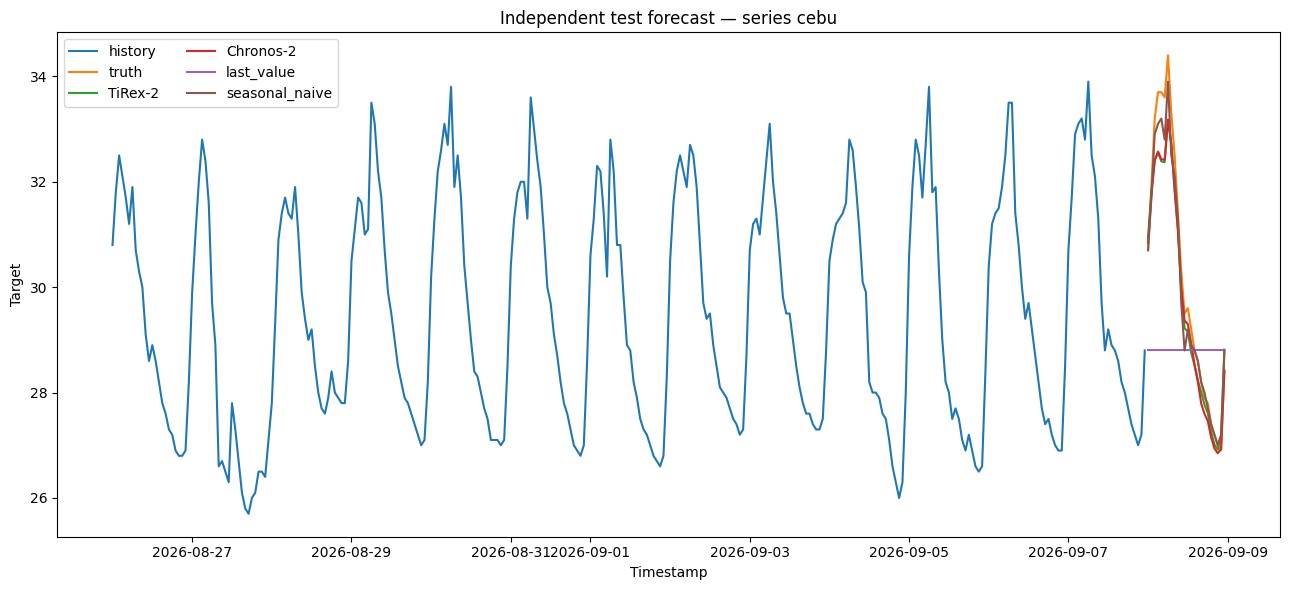

In [14]:
# @title 9.2 Plot the test forecasts
PLOT_SERIES = panel["series_ids"][0]
history_plot = test_history[test_history["series_id"] == PLOT_SERIES]
truth_plot = test_truth[test_truth["series_id"] == PLOT_SERIES]
forecast_plot = test_all[test_all["series_id"] == PLOT_SERIES]

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(history_plot["timestamp"], history_plot["target"], label="history")
ax.plot(truth_plot["timestamp"], truth_plot["target"], label="truth")
for model, block in forecast_plot.groupby("model", sort=False):
    ax.plot(block["timestamp"], block["prediction"], label=model)
ax.set_title(f"Independent test forecast — series {PLOT_SERIES}")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Target")
ax.legend(ncol=2)
plt.tight_layout()
plt.savefig(OUTPUT_ROOT / "figures" / "test_forecasts.png", dpi=150, bbox_inches="tight")
plt.show()

## Test checkpoint

1. Did any model's error change a lot between validation and test? What changed in its input?
2. Did the ranking of the models change?
3. Look at coverage and width together. Would you prefer a narrower band that misses more often, or a wider band that almost never misses?
4. On the Open-Meteo sample, compare macro MAE with macro skill. Can they disagree?

<details>
<summary><b>Show a sample answer</b></summary>

**Synthetic sample (test, 72 hours of context)**

1. TiRex-2 improved sharply: macro MAE 2.81 on validation, 1.15 on test (`A` 1.76, `B` 0.54). Chronos-2 improved from 0.27 to 0.18. The test forecast uses 24 more hours of context, but it also has a later forecast origin and a different target period. These results do not isolate the effect of history length. To test that effect, vary only the context length at a fixed forecast origin and score the same validation targets.
2. No. Chronos-2 (skill 0.95) stayed ahead of TiRex-2 (0.70), and both beat seasonal naive (3.60) and last value (5.53).
3. Both models covered every test value. Chronos-2 did it with a band less than half as wide (about 2.0 against 4.6), so its band is more informative. Which you prefer in practice depends on what a miss costs compared with an over-cautious plan.

**Open-Meteo sample (test day 2026-09-08)**

1. Not much: macro MAE 0.45 for Chronos-2 and 0.46 for TiRex-2, against 0.50 and 0.56 on validation.
2. The two models stayed close. Coverage moved nearer to 0.80: 0.76 for Chronos-2 and 0.82 for TiRex-2.
3. Here TiRex-2's slightly wider band caught more true values. Neither choice is right in general.
4. Yes. Both models have a lower macro MAE than seasonal naive (0.45 and 0.46 against 0.50), yet a negative macro skill (−0.03 and −0.06). In Cebu, 2026-09-08 closely repeated the day before, so seasonal naive scored MAE 0.30 and both models had skill below −0.5. Averaging skill per city lets that one city outweigh the gains in Manila (+0.3) and Davao (+0.1). Always read the per-series table.

</details>


# 10. Compare accuracy with cost

**Evaluation practice.**

Forecast error is only one dimension. The next table combines each model's checkpoint size with its measured load time, forecast time and device on the test run.

In the reference Colab T4 run, TiRex-2 (363 MiB, CPU) loaded in about 7–14 seconds and forecast in about 8 seconds. Chronos-2 (456 MiB, GPU) loaded in about 7–8 seconds and forecast in about 2 seconds. Toto 2.0's checkpoint is 9.8 GB (9,362 MiB) and needs a GPU.

Questions to consider:

- Did a foundation model beat seasonal naive on every series?
- If two models are close in error, does one have a much smaller footprint?
- Does any measured improvement justify the additional compute and model footprint for this problem?
- Would the 9.8 GB Toto model be justified for this forecasting workload? Would the answer change for thousands of series?

There is no single correct answer, and this notebook does not prescribe one.

**Predict first.** If two models have similar MAE, which would you choose given their footprint and speed? Predict the trade-off before inspecting the cost table.


In [15]:
# @title 10.1 Compare model size and measured runtime
tradeoff_rows = []
for name in SELECTED_MODELS:
    meta = test_runtime[name]
    tradeoff_rows.append({
        "model": MODEL_SPECS[name]["display_name"],
        "checkpoint_MiB": round(MODEL_SPECS[name]["weight_bytes"] / 2**20, 1),
        "device": meta.get("device"),
        "load_seconds": meta.get("load_seconds"),
        "inference_seconds": meta.get("inference_seconds"),
        "wall_seconds": meta.get("wall_seconds"),
    })
tradeoffs = pd.DataFrame(tradeoff_rows)
display(tradeoffs)
tradeoffs.to_csv(OUTPUT_ROOT / "test" / "computational_tradeoffs.csv", index=False)

,model,checkpoint_MiB,device,load_seconds,inference_seconds,wall_seconds
0,TiRex-2,363.0,cpu,13.711810,8.857147,24.591575
1,Chronos-2,455.8,cuda,6.679057,2.853780,11.043037


# 11. Forecast the real future

**Core concept.**

Now every available hour becomes context, and each model forecasts the 24 hours after the data ends. Those hours have not been observed in this dataset, so the forecast is marked **not measurable yet**.

This separates two ideas:

- **backtesting:** forecasting a past period whose truth is known, so it can be scored, as in Sections 7 and 9;
- **real future inference:** a forecast that is available now, but whose truth has not happened yet.


In [16]:
# @title 11.1 Forecast the next 24 hours
future_frames = []
future_runtime = {}
for name in SELECTED_MODELS:
    print("future:", name)
    forecast_frame, meta = run_model(
        name, "future", WORK_ROOT / "requests" / "future_history.csv", future_horizon
    )
    future_frames.append(forecast_frame)
    future_runtime[name] = meta

future_forecasts = pd.concat(future_frames, ignore_index=True)
future_forecasts.to_csv(OUTPUT_ROOT / "future" / "forecasts.csv", index=False)
(OUTPUT_ROOT / "future" / "runtime.json").write_text(
    json.dumps(future_runtime, indent=2), encoding="utf-8"
)

display(future_forecasts.head(12))
print("Evidence status: not-measurable — no future truth exists yet.")

future: tirex
future: chronos


,model,partition,forecast_origin,series_id,timestamp,step,q0.1,q0.5,q0.9,prediction
0,TiRex-2,future,2026-09-08 23:00:00,cebu,2026-09-09 00:00:00,1,29.945341,30.524281,31.131027,30.524281
1,TiRex-2,future,2026-09-08 23:00:00,cebu,2026-09-09 01:00:00,2,30.946114,31.734428,32.526299,31.734428
2,TiRex-2,future,2026-09-08 23:00:00,cebu,2026-09-09 02:00:00,3,31.621075,32.593288,33.511662,32.593288
3,TiRex-2,future,2026-09-08 23:00:00,cebu,2026-09-09 03:00:00,4,31.734827,32.820923,33.790310,32.820923
4,TiRex-2,future,2026-09-08 23:00:00,cebu,2026-09-09 04:00:00,5,31.655586,32.788353,33.819950,32.788353
5,TiRex-2,future,2026-09-08 23:00:00,cebu,2026-09-09 05:00:00,6,31.553217,32.753838,33.830307,32.753838
6,TiRex-2,future,2026-09-08 23:00:00,cebu,2026-09-09 06:00:00,7,32.107220,33.402172,34.429897,33.402172
7,TiRex-2,future,2026-09-08 23:00:00,cebu,2026-09-09 07:00:00,8,31.525900,32.851379,33.959328,32.851379
8,TiRex-2,future,2026-09-08 23:00:00,cebu,2026-09-09 08:00:00,9,30.740580,32.005699,33.164940,32.005699
9,TiRex-2,future,2026-09-08 23:00:00,cebu,2026-09-09 09:00:00,10,30.021490,31.163797,32.295681,31.163797


Evidence status: not-measurable — no future truth exists yet.


# 12. Interpret the evidence

**Evaluation practice.**

## Write an evidence-based conclusion

Use this structure.

**1. State the question.**

> We tested whether pretrained time-series foundation models, used zero-shot, improved 24-hour-ahead forecasts relative to last-value and seasonal-naive baselines on **[sample]**.

**2. Report the primary result.**

> On the frozen test period, **[model]** obtained a macro MAE of **[value]** and a skill of **[value]** against seasonal naive, whose MAE was **[value]**.

**3. Report the per-series picture.**

> On **[series]**, **[model]** **[beat / did not beat]** seasonal naive (skill **[value]**).

**4. Report the uncertainty.**

> Its q10–q90 band covered **[value]** of test values with an average width of **[value]**.

**5. Weigh the cost.**

> It needed **[size]** of weights and **[time]** on **[device]**.

**6. State the limitations and avoid overclaiming.**

Prefer: *"On this sample and forecast origin, model A had lower MAE than model B."* Avoid: *"Model A is the best forecasting model."*

## Limitations to state

- **The samples are small.** The synthetic sample was deliberately constructed to be understandable, and the Open-Meteo sample covers three grid cells over 14 days. Performance on them is **tutorial evidence only**.
- **No universal ranking.** One validation and one test forecast origin cannot establish general model superiority. Real evaluation uses many rolling origins across representative periods.
- **Baselines are mandatory.** A foundation model that cannot consistently improve on seasonal naive may not be worthwhile for the application.
- **Quantiles are not guaranteed intervals.** q0.1 and q0.9 describe the model's predictive distribution. They are not guaranteed to contain the truth 80% of the time on new data; calibration must be checked on real forecast history.
- **Distribution shift.** Real forecasting problems include structural breaks, missing data, promotions, incidents, changing sensors, changed policies, evolving demand, interventions and nonstationarity. The synthetic sample represents none of these; the Open-Meteo sample shows only ordinary weather changes.
- **Pretraining overlap.** The Open-Meteo dates are after all three models were released, so these values cannot be in their pretraining data. Weather from earlier periods may be.
- **Decisions.** Forecasts should not drive high-consequence decisions without representative backtesting, monitoring, fallback procedures and human oversight.

## Participant submission checklist

- [ ] Sample name and SHA-256 digest, or your own file's digest
- [ ] Tier, selected models and their revisions
- [ ] Software versions from Section 1
- [ ] Your EDA checkpoint answers
- [ ] The validation comparison table
- [ ] The frozen test comparison table, overall and per series
- [ ] Coverage and width for each foundation model
- [ ] The runtime and footprint table
- [ ] One evidence-based conclusion
- [ ] At least three limitations
- [ ] Licence notes: model weights, and the data licence (credit Open-Meteo if you used its data)

### Suggested scoring guide

| Criterion | Weight |
|---|---:|
| Reproducible setup and provenance | 15% |
| Correct use of validation and test periods | 20% |
| Data exploration and interpretation | 15% |
| Controlled comparison against baselines | 20% |
| Uncertainty and per-series analysis | 15% |
| Evidence-based conclusion and limitations | 15% |


# 13. Export the experiment record

**Infrastructure.**

The next cell writes the model manifest and the experiment manifest, writes a short run summary (`workshop_summary.json`), then zips the whole output folder into a report bundle and prints its SHA-256. The bundle holds the forecasts, the metric tables, the freeze file, the figures and the manifests, so anyone with the same notebook revision and data can check your numbers.

The final cell prints a one-table summary of the run.


In [17]:
# @title 13.1 Export the experiment record
import datetime
import shutil

def file_sha(path):
    h = hashlib.sha256()
    with open(path, "rb") as fh:
        for chunk in iter(lambda: fh.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

model_manifest = {
    name: {
        "display_name": MODEL_SPECS[name]["display_name"],
        "model_id": MODEL_SPECS[name]["model_id"],
        "revision": MODEL_SPECS[name]["revision"],
        "license": MODEL_SPECS[name]["license"],
        "runtime_package": MODEL_SPECS[name]["runtime_package"],
        "files": {
            filename: {"bytes": size, "sha256": digest}
            for filename, (size, digest) in MODEL_SPECS[name]["files"].items()
        },
        "runner_sha256": source_sha(name),
    }
    for name in SELECTED_MODELS
}

experiment_manifest = {
    "notebook_spec": "2.1",
    "notebook_profile": "TASK-INFERENCE",
    "notebook_mode": "WORKSHOP",
    "workshop_revision": "0.1.0-candidate",
    "timestamp_utc": datetime.datetime.now(datetime.timezone.utc).isoformat(),
    "execution_tier": WORKSHOP_TIER,
    "dataset": dataset_manifest,
    "protocol": {
        "validation_context_steps": int(
            validation_history.groupby("series_id").size().min()
        ),
        "validation_horizon": VALIDATION_HORIZON,
        "test_context_steps": int(test_history.groupby("series_id").size().min()),
        "test_horizon": TEST_HORIZON,
        "season_length": SEASON_LENGTH,
        "quantiles": list(QUANTILES),
        "point_forecast": "q0.5 model median",
    },
    "models": model_manifest,
    "test_metrics": test_aggregate.to_dict("records"),
    "standalone_contract": {
        "repository_clone_required": False,
        "dimer_source_runtime_fetch_required": False,
        "external_dimer_worker_required": False,
        "credential_required": False,
        "default_upload_required": False,
    },
    "evidence_scope": (
        {
            "synthetic": "Synthetic tutorial sample",
            "open_meteo_ph": "Open-Meteo real-data sample (3 grid cells, 14 days)",
        }.get(sample_kind, "User-supplied data")
        + "; one validation origin and one independent test origin. "
        "Results are sample-sanity evidence, not a model benchmark."
    ),
}

(OUTPUT_ROOT / "provenance" / "model_manifest.json").write_text(
    json.dumps(model_manifest, indent=2), encoding="utf-8"
)
(OUTPUT_ROOT / "provenance" / "experiment_manifest.json").write_text(
    json.dumps(experiment_manifest, indent=2), encoding="utf-8"
)

summary = {
    "tier": WORKSHOP_TIER,
    "models": [MODEL_SPECS[name]["display_name"] for name in SELECTED_MODELS],
    "sample_sha256": input_sha256,
    "test_metrics": test_aggregate.to_dict("records"),
    "future_forecast_status": "not-measurable",
}
(OUTPUT_ROOT / "workshop_summary.json").write_text(
    json.dumps(summary, indent=2), encoding="utf-8"
)

bundle = shutil.make_archive(
    str(Path(OUTPUT_DIR).resolve()) + "_DIMER_TimeSeries_FM_Workshop_Report",
    "zip",
    root_dir=Path(OUTPUT_DIR).resolve(),
)

print({
    "output_directory": str(OUTPUT_ROOT.resolve()),
    "report_bundle": bundle,
    "report_bundle_sha256": file_sha(bundle),
})

{'output_directory': '/content/outputs', 'report_bundle': '/content/outputs_DIMER_TimeSeries_FM_Workshop_Report.zip', 'report_bundle_sha256': 'f576516743c3a6decb0301ef3247ccc44d92cddcc0ff47a59ac64cc9debf2e9e'}


In [18]:
# @title 13.2 Run-all completion summary
completion = {
    "notebook_spec": "2.1",
    "profile": "TASK-INFERENCE",
    "mode": "WORKSHOP",
    "tier": WORKSHOP_TIER,
    "models": [MODEL_SPECS[name]["display_name"] for name in SELECTED_MODELS],
    "sample_kind": sample_kind,
    "sample_sha256": input_sha256,
    "validation_context": int(validation_history.groupby("series_id").size().min()),
    "validation_horizon": VALIDATION_HORIZON,
    "test_context": int(test_history.groupby("series_id").size().min()),
    "test_horizon": TEST_HORIZON,
    "future_horizon": future_horizon,
    "output_directory": str(OUTPUT_ROOT.resolve()),
}
display(pd.Series(completion, name="value").to_frame())

print(
    "Default notebook path complete. "
    "Treat all metrics from these samples as tutorial/sanity evidence, not benchmark evidence."
)

,value
notebook_spec,2.1
profile,TASK-INFERENCE
mode,WORKSHOP
tier,STANDARD
models,"[TiRex-2, Chronos-2]"
sample_kind,open_meteo_ph
sample_sha256,74163ee609cda87869b7c13f4c2aa59343f94b4ba42d2e...
validation_context,288
validation_horizon,24
test_context,312


Default notebook path complete. Treat all metrics from these samples as tutorial/sanity evidence, not benchmark evidence.


# Optional extensions

These exercises are separate from the frozen comparison. These advanced extensions require additional code. Start with the ready-made validation-only activity after the glossary for a bounded change-one-thing experiment.

**A. Context length.** On the validation period only, give the models shorter histories, such as 32 versus 48 hours on the synthetic sample. Keep the same forecast origin and validation targets, and never request more history than is available before that origin. Does more history always help? Section 9 alone cannot answer this because it compares different target periods. Do not use the test period to choose a context length.

**B. Structural break.** Add a synthetic series with a trend, a daily cycle and a sudden level shift late in the history. Does pretraining protect the models from a change they have not seen?

**C. Covariates.** TiRex-2 and Chronos-2 can use extra inputs known in advance, such as calendar features. Such an experiment must stay outside the common comparison, because Toto's open interface here has no equivalent. A future target value, or anything computed from one, is leakage and must be refused.


# Appendix A. Instructor and reproducibility notes

**Standalone contract.** The default path does not clone a repository, download or import DIMER source, call a DIMER worker or API, or need a token. It generates or loads a digest-checked sample, checks the data before any model download, runs zero-shot inference through pinned upstream packages in isolated environments, freezes the experiment before the test period, and exports forecasts, metrics and provenance. BYOD never blocks **Run all**.

**Before teaching.** Run the chosen tier in a clean Colab session with both samples. Recorded clean runs are listed in `docs/release-verification.md` in the Chronos-2 pipeline repository; the sample answers in this notebook quote the reference runs. Run `FULL` separately on the machine you will teach from: it downloads a 9.8 GB checkpoint.

**Common comparison boundary.** Only the intersection of the selected models' capabilities is used: finite numerical targets, regular sampling, no covariates, context of at most 8,192, horizon of at most 1,024, and quantiles 0.1 / 0.5 / 0.9 with the point forecast equal to q0.5.

**Isolation.** Each model runs in its own `uv`-built Python 3.12 environment with exact package pins; the notebook's own kernel only orchestrates, checks data, scores and plots.

# Appendix B. Model and data references

| Model | Hugging Face repository | Pinned revision | Weight licence |
|---|---|---|---|
| TiRex-2 | [`NX-AI/TiRex-2`](https://huggingface.co/NX-AI/TiRex-2) | `05e5b26db52bfb256f1ae1bdf785589850482de3` | Apache-2.0 |
| Chronos-2 | [`amazon/chronos-2`](https://huggingface.co/amazon/chronos-2) | `95a9710e2596287d08352589f42634fa5abdf0a7` | Apache-2.0 |
| Toto 2.0 2.5B | [`Datadog/Toto-2.0-2.5B`](https://huggingface.co/Datadog/Toto-2.0-2.5B) | `51a2812bbe449437c01b79c0e425ed578f335f5b` | Apache-2.0 |

- Chronos-2 paper: [arXiv:2510.15821](https://arxiv.org/abs/2510.15821).
- Synthetic sample: `examples/sample-data/` in [`kurtvalcorza/chronos-2-forecasting-pipeline`](https://github.com/kurtvalcorza/chronos-2-forecasting-pipeline), including its dataset card and generator.
- Open-Meteo sample: `examples/byod-data/open-meteo-ph-temperature/` in the same repository, including the fetch script and dataset card. Weather data by [Open-Meteo.com](https://open-meteo.com/), CC BY 4.0.
- Design contract for this notebook: `docs/multimodel-forecasting-workshop-spec.md` in the same repository.


# Troubleshooting

| What you see | Likely cause | What to do |
|---|---|---|
| The notebook's Python is older than 3.10 | Unsupported notebook runtime | Use a current Colab or Kaggle runtime. The models use their own Python 3.12 |
| `uv venv --python 3.12` fails | The runtime could not download a standalone Python 3.12 | Rerun with internet access, or use a runtime that already has Python 3.12 |
| An environment install fails | Network interruption | Rerun Section 6 |
| TiRex fails when a GPU is present | Its software tries to compile GPU code | Use the runner as written; it hides the GPU from TiRex-2 |
| A model's checkpoint hash fails | Incomplete or changed download | Delete that model's folder under `work/model_cache/` and rerun. Never bypass the check |
| Toto fails with `Key backend: 'module://matplotlib_inline.backend_inline' is not a valid value` | The notebook's plotting setting leaked into the model environment | Use the runner as written; it sets `MPLBACKEND=Agg` for every model |
| Toto says CUDA is unavailable | `FULL` selected without a GPU | Select a GPU runtime, or switch to `STANDARD` |
| Toto's download fills the disk | 9.8 GB checkpoint plus packages | Use `STANDARD`, or a runtime with more storage |
| Your timestamps are rejected | Irregular or gappy timestamps | Clean the file outside the notebook and note the change. The notebook will not resample |
| Your values are rejected | Missing, non-numeric or infinite values | Supply finite numbers only |
| The seasonal baseline fails | Less history than one seasonal period | Use more history or a shorter `SEASON_LENGTH` |
| A model loses to seasonal naive | A simple pattern dominates the data | This is a valid result, not an error |
| A run fails with a message naming a model | That model's program failed | Read the error text printed below the message |

The notebook stops with an explicit error rather than silently changing the forecasting problem.

# Glossary

| Term | Meaning in this notebook |
|---|---|
| **Backtesting** | Forecasting a past period whose truth is known, so the forecast can be scored |
| **Baseline** | A simple reference method that a complex model must beat |
| **Checkpoint (model)** | The file of trained weights that defines a pretrained model |
| **Context** | The history available to a model at the forecast origin |
| **Coverage** | The fraction of true values inside the q0.1–q0.9 band |
| **Distribution shift** | A change between the history and the period being forecast |
| **Forecast horizon** | How many future steps are forecast, here 24 hours |
| **Forecast origin** | The last observed time before the forecast period |
| **Foundation model** | A large model pretrained on broad data, applied to new tasks with little or no extra training |
| **Freeze** | Recording the chosen models and settings before scoring the test period |
| **Frequency** | The spacing between timestamps, here one hour |
| **Interval width** | The average distance between q0.1 and q0.9 |
| **Last-value baseline** | Repeats the final observed value for every future hour |
| **Leakage** | Information from the period being forecast reaching the model or your choices |
| **MAE** | Mean absolute error: the average size of the errors, in the data's units |
| **Macro average** | The average of per-series scores, each series weighted equally |
| **Model median (q0.5)** | The model's middle estimate, used as the point forecast |
| **Pinball loss** | A score for one quantile forecast that penalises misses on the wrong side more heavily |
| **Pinned revision** | An exact, unchangeable version of a model repository |
| **Pooled score** | A score over all rows of all series together; depends on scale |
| **Quantile forecast** | A value below which the model expects the truth to fall a stated fraction of the time |
| **Residual** | True value minus forecast |
| **RMSE** | Root mean squared error; weighs large misses more than MAE |
| **Seasonal naive** | Repeats the same hour from the previous 24-hour cycle |
| **Seasonal period** | The length of a repeating cycle, here 24 hours |
| **SHA-256 digest** | A 64-character fingerprint of a file's bytes |
| **Skill** | 1 − model MAE / seasonal-naive MAE; above 0 means the model beats seasonal naive |
| **Test period** | The period kept aside and scored once, after the freeze |
| **Time series** | Values of one quantity recorded at regular times |
| **Validation period** | The period used to compare models and make choices |
| **Virtual environment** | A separate set of installed Python packages |
| **Zero-shot forecasting** | Forecasting with pretrained weights only, without training on the series |


# Optional activity: change one seasonal assumption

**Evaluation practice — Predict → Change one thing → Run → Observe → Explain.**

Question: does repeating the previous 24-hour cycle predict this validation period better than repeating a 12-hour cycle? This is a baseline experiment, not a foundation-model context-length experiment.

1. **Predict:** write which period (12 or 24 hours) should have lower MAE for each series, and why.
2. **Change one thing:** enable `RUN_SEASONAL_ACTIVITY` below. The only experimental difference between the two conditions is the seasonal-naive period; the history, forecast origin, horizon, target rows and MAE calculation stay fixed.
3. **Run:** execute only the activity cell. It uses the existing validation split, requires no model downloads and does not rerun or modify the test comparison. It is disabled during default Run all.
4. **Observe:** compare each series' MAE and the macro average. A lower value is better. The result may differ by series or sample.
5. **Explain:** state whether the evidence agrees with your prediction and why. Do not use this post-run activity to revise the already-frozen comparison or claim a new independent test result. A new selection experiment needs a new untouched holdout.

The cell writes a separate `activities/seasonal_period_comparison.csv` under the output directory. This optional file is not part of the report ZIP created earlier; save it separately with your conclusion.


In [19]:
# @title Optional validation-only seasonal-period comparison
RUN_SEASONAL_ACTIVITY = False  # @param {type:"boolean"}

def compare_seasonal_periods(history, truth):
    rows = []
    for period in (12, 24):
        predictions = baseline_forecast(history, truth, "seasonal_naive", season_length=period)
        paired = predictions.merge(
            truth[["series_id", "timestamp", "target"]],
            on=["series_id", "timestamp"], validate="one_to_one",
        )
        if len(paired) != len(truth):
            raise ValueError("Activity predictions must cover the same validation targets")
        for sid, block in paired.groupby("series_id", sort=True):
            rows.append({"season_length": period, "series_id": sid,
                         "mae": mae(block["target"], block["prediction"])})
    return pd.DataFrame(rows)

if RUN_SEASONAL_ACTIVITY:
    seasonal_activity = compare_seasonal_periods(validation_history, validation_truth)
    display(seasonal_activity)
    display(seasonal_activity.groupby("season_length")["mae"].mean().rename("macro_mae"))
    activity_directory = OUTPUT_ROOT / "activities"
    activity_directory.mkdir(exist_ok=True)
    seasonal_activity.to_csv(activity_directory / "seasonal_period_comparison.csv", index=False)
else:
    print("Optional activity skipped; the frozen experiment is unchanged.")


Optional activity skipped; the frozen experiment is unchanged.


### What to notice and explain

<details>
<summary>Show a sample interpretation</summary>

The synthetic sample contains a 24-hour cycle, so repeating 12 hours can put peaks where troughs belong. A 24-hour repeat still misses the upward trend. On real weather data, read each city's result rather than assuming the same ordering. Both conditions use the same validation targets, so the difference measures the effect of the baseline's seasonal-period setting on this sample. It does not establish that more foundation-model context helps, that one model is universally superior, or that a validation-selected setting will generalise.

</details>

**Your conclusion:** On [sample and series], changing only the seasonal period from 12 to 24 changed validation MAE from [value] to [value]. This [agreed/disagreed] with my prediction because [reason]. The main limitation is [one origin / small sample / domain shift].
